# Solution System Design and Architecture

**AIAT 126 · Unit 2 · 15 hours (3 theory + 12 practical)**

## 🔗 Builds on (AIAT 111–125)

AIAT 126 is the *graduation* project: it **assembles** what you already built across the diploma, it does not re-teach it. Open what you need:

- **AIAT 114 U1 — the preprocessing-pipeline pattern this design ships as an artifact** → [`Course 04/unit1-regression-algorithms/examples/03_data_preprocessing.ipynb`](../../../Course%2004/unit1-regression-algorithms/examples/03_data_preprocessing.ipynb)
- **AIAT 114 U3 — the classifiers your selection matrix chooses between** → [`Course 04/unit3-classification/examples/01_logistic_regression.ipynb`](../../../Course%2004/unit3-classification/examples/01_logistic_regression.ipynb)
- **AIAT 115 U5 — production pipelines and reading files too big for memory** → [`Course 05/unit5-scaling/examples/05_production_pipelines.ipynb`](../../../Course%2005/unit5-scaling/examples/05_production_pipelines.ipynb)
- **AIAT 125 U2 — packaging and serving, the target your design points at** → [`Course 11/unit2-versioning-serving/examples/02_fastapi_deployment.ipynb`](../../../Course%2011/unit2-versioning-serving/examples/02_fastapi_deployment.ipynb)
- **AIAT 125 U5 — monitoring and drift, the observability lane of the diagram** → [`Course 11/unit5-pipelines-monitoring/examples/04_drift_detection.ipynb`](../../../Course%2011/unit5-pipelines-monitoring/examples/04_drift_detection.ipynb)
- **AIAT 116 U2 — bias detection, for the legal/ethical risk this design must name** → [`Course 06/unit2-bias-fairness/examples/01_bias_detection.ipynb`](../../../Course%2006/unit2-bias-fairness/examples/01_bias_detection.ipynb)
- **AIAT 122 U2 — only if your system takes images** → [`Course 08/unit2-cnns/examples/01_cnn_architecture.ipynb`](../../../Course%2008/unit2-cnns/examples/01_cnn_architecture.ipynb)
- **AIAT 121 U3 — only if your system takes text** → [`Course 07/unit3-ml-for-nlp/examples/01_text_classification.ipynb`](../../../Course%2007/unit3-ml-for-nlp/examples/01_text_classification.ipynb)

Record every artifact you reuse in **section 6, the Prior Work Inventory**, of [`TEMPLATES/project_proposal_template.md`](../../TEMPLATES/project_proposal_template.md). It is scored at gate 1 (criterion 1.7) and re-checked at the Unit 2 design review — it is this course's **CLO2** evidence, and the official AIAT 126 description requires it.

## 🔗 Where this leads

**Used later in:** Course 12 — Unit 3, which implements this design, and Unit 4, which tests it against the evaluation plan written here.

---

## Lesson Brief

Unit 1 gave you an approved **proposal**: a problem, users, objectives, a dataset and a timeline.
This unit turns that proposal into a **design** — the document a reviewer reads *before* you are
allowed to write model code, and the single cheapest place in the whole project to catch an
expensive mistake.

The deliverable of this unit is a **design document** (gate 2, 10 points). By the end of this
notebook you will have generated one, from your own answers, with a validator that refuses to
emit a document that still contains `TODO`.

## Learning Objectives

By completing this notebook, you will be able to:

1. Decompose an AI system into **components** with explicit inputs, outputs and owners.
2. Draw an **architecture and data-flow diagram** that provably matches your component list.
3. Justify your **model, algorithm, dataset and platform** choices against your own data and constraints — and back the justification with a measurement.
4. Write a **data-collection and preprocessing plan** derived from a profile of the real data, not from a template.
5. Choose **evaluation metrics and baselines** before training, and set a "must beat" threshold.
6. Specify **input/output formats and storage** concretely enough for someone else to implement.
7. Plan for **scalability, modularity and integration**, using a measurement rather than a guess.
8. Produce the **design document** deliverable for your own capstone.

## Prerequisites

- Unit 1 completed: an approved proposal with a named dataset.
- The whole diploma: this unit assumes you can already train, evaluate and serve a model. It is about deciding *which* ones and *how they fit together*.

## 📥 Inputs & 📤 Outputs

**Inputs**

- The **1912 Titanic passenger manifest** — `../../../Course 04/datasets/raw/titanic.csv` (891 rows × 12 columns). It carries real missingness (`Age` 19.9%, `Cabin` 77.1%, `Embarked` 0.2%), a real class imbalance, and a real fairness problem, so every design decision below has to survive contact with messy data.
- The **credit-card fraud transactions** file — `../../../Course 04/datasets/raw/creditcard_fraud.csv` (284,807 rows) — used only in Part 7, to *measure* how the pipeline scales instead of guessing.
- **Your own project** answers, in Part 8.

**Outputs**

- A component registry and a rendered architecture/data-flow diagram.
- A weighted model-selection matrix, plus measured validation numbers that confirm or contradict it.
- A data plan generated from a real column profile, an evaluation plan with two real baselines, a real saved model artifact with its real byte size, and a real scaling measurement.
- `design_document_example.md` — the worked design document, written to disk next to this notebook.
- A validated design document for **your** project (once your `my_design` has no `TODO` left).

---

---

## The design that downgraded 39% of England's A-level grades

In summer 2020 the UK cancelled its A-level exams. In England grades still had to be issued, so the regulator **Ofqual** built a standardisation model: take each school's teacher-assessed grades, then adjust them using **that school's historical performance in that subject**. The model was specified, reviewed and signed off before it produced a single grade. It was, in the sense this notebook means, a *design*.

Two design decisions decided the outcome. First, **which feature the model would lean on** — a centre's past results rather than the individual pupil in front of it. Second, **a cohort-size rule**, applied to a school's entry in that subject averaged across the current year and its history: below **five**, the teacher's grades stood untouched; between **five and fifteen** the two were blended on a sliding scale; **above fifteen**, the teacher's judgement was displaced entirely by the statistical model. Ofqual's own thresholds, in its own notation, were `n_thresh = 5` and `n_small = 15`.

On results day **39.1% of A-level grades in England came out below the teacher's assessment** — 35.6% down one grade, 3.3% down two and 0.2% down three or more, out of 718,276 entries (Ofqual, *interim report*, 13 August 2020, Table 9.8). The cohort rule fell unevenly: small classes are far more common in the fee-paying sector, so the pupils most likely to be *exempted* from the model were not the pupils most likely to be *downgraded* by it. After several days of public protest, on **17 August 2020** the government reversed the policy and awarded teacher-assessed grades after all.

Nothing in that story is a coding bug. Every consequential decision — which feature, which threshold, which exemption rule — is exactly the kind of decision you are about to write down in **Part 3**, **Part 4** and **Part 5** of this notebook.

### What goes wrong without this

Your project makes these decisions whether or not you write them down. Without a design, it makes them implicitly, one line of code at a time, where nobody can see them and nobody can argue with them. Then in week 11 you discover that the scaler was fitted before the split, that your strongest feature is one you are not allowed to use, or that the diagram in your report shows a cache your code never had. Each of those is a two-minute conversation at design review and a two-week rebuild afterwards.

### The same reasoning, three other domains

- **Knight Capital, 1 August 2012.** New order-routing code went to seven of the firm's eight servers. On the eighth, a repurposed flag re-activated dormant "Power Peg" code. While processing just **212** customer orders, the system poured millions of child orders into the market over about **45 minutes**, obtaining **more than 4 million executions** in 154 stocks for over **397 million shares**; Knight lost **more than $460 million** (SEC Administrative Proceeding 34-70694, 16 October 2013). This is an *artifact-contract* failure: two paths that were supposed to be running the same thing were not, and nothing in the system could tell.
- **Amazon's experimental résumé screener, reported October 2018.** A model trained on ten years of applications learned to penalise résumés containing the word "women's" and to downgrade graduates of two all-women's colleges. Amazon says it was never used by recruiters to evaluate candidates. A *feature-selection* decision, made at design time, that encoded who had applied before as who should be hired next.
- **"Hidden Technical Debt in Machine Learning Systems" (Sculley et al., NeurIPS 2015).** The Google paper that named *glue code*, *pipeline jungles* and *hidden feedback loops*, and drew the picture the lane diagram below is a compressed version of: "only a small fraction of real-world ML systems is composed of the ML code, as shown by the small black box in the middle" (Figure 1). Almost all the failures live outside that box.

One pattern, three industries: **the decisions that decided the outcome were all made before anyone measured anything.** That is what a design review is for.

In [1]:
# Setup: this is a design lesson, so the toolkit is deliberately the standard course stack —
# pandas/NumPy for the real data, matplotlib for the architecture diagram we draw ourselves,
# scikit-learn for the measurements that back the design decisions, joblib for the artifact
# store. WHY no new library: a design document that depends on something exotic is a design
# document nobody on your team can review.
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import Markdown, display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
import joblib

# Fixed seed: the split below must be identical every time the design is reviewed,
# otherwise the numbers in the design document cannot be checked by anyone else.
RANDOM_STATE = 42

TITANIC = Path("../../../Course 04/datasets/raw/titanic.csv")
FRAUD = Path("../../../Course 04/datasets/raw/creditcard_fraud.csv")

print("Libraries imported.")
print(f"Titanic manifest present: {TITANIC.exists()}")
print(f"Fraud transactions present: {FRAUD.exists()}")

Libraries imported.
Titanic manifest present: True
Fraud transactions present: True


---

## Part 1 — System components and architecture

A **component** is a part of the system with one job, a declared input and a declared output.
"The model" is not a component list. This is:

| What a component declaration must state | Why a reviewer needs it |
|---|---|
| **id** | so the data flow and the diagram can refer to it unambiguously |
| **what it does** — one verb phrase | a component you cannot describe in one line is really two components |
| **reads / writes** | this is the interface; it is what lets someone else build the component |
| **lane** | *when* it runs — see below |

### The four lanes

Almost every AI system separates into four lanes, and mixing them up is the most common
first-draft error in this course:

1. **Training path** — runs *offline*, on a schedule or on demand. It is allowed to be slow.
2. **Artifacts** — the fitted model, the fitted preprocessing, the schema, the metrics. This is the **contract** between the two paths. If the training path writes something the serving path does not read, one of them is wrong.
3. **Serving path** — runs *online*, once per request. It is not allowed to be slow, and it may not refit anything.
4. **Observability** — how you find out the system broke without a user telling you.

The single most valuable thing this separation buys you: **the preprocessing must be an
artifact, not a code path**. If the serving lane re-implements the cleaning steps, training
and serving will drift apart — this is called training/serving skew, and it is the defect
Unit 3 spends the most effort teaching you to avoid.

Below, the components are written as **data**, not prose. That matters: in Part 2 the diagram
is drawn *from this list*, so the picture cannot silently disagree with the design.

In [2]:
# Component registry for the worked example: a survival-risk scoring service built on the
# real 1912 Titanic manifest. WHY write components as a list of dicts instead of prose:
# the diagram in Part 2, the consistency checks, and the final design document are all
# generated from this one structure, so they can never contradict each other.
# 'lane' says WHEN a component runs; 'reads'/'writes' are its interface contract.
COMPONENTS = [
    {"id": "source", "lane": "train", "col": 0,
     "name": "1. Data source",
     "does": "Titanic manifest CSV · 891 rows × 12 cols",
     "reads": "titanic.csv (read-only, licensed for coursework)",
     "writes": "raw DataFrame"},
    {"id": "prep", "lane": "train", "col": 1,
     "name": "2. Preprocessing",
     "does": "impute · encode · scale (fit on TRAIN only)",
     "reads": "raw DataFrame",
     "writes": "feature matrix + a FITTED transformer object"},
    {"id": "train", "lane": "train", "col": 2,
     "name": "3. Training",
     "does": "2 candidates, chosen on validation",
     "reads": "feature matrix (train split)",
     "writes": "fitted estimator + validation metrics"},
    {"id": "store", "lane": "store", "col": 2,
     "name": "4. Artifact store",
     "does": "model.joblib · schema.json · metrics.json",
     "reads": "fitted estimator, fitted transformer, metrics",
     "writes": "versioned files on disk"},
    {"id": "request", "lane": "serve", "col": 0,
     "name": "5. Request",
     "does": "one passenger record as JSON",
     "reads": "caller input",
     "writes": "validated record matching schema.json"},
    {"id": "serve", "lane": "serve", "col": 1,
     "name": "6. Scoring service",
     "does": "loads artifacts, applies the same preprocessing",
     "reads": "schema-valid record + artifacts",
     "writes": "probability + label"},
    {"id": "response", "lane": "serve", "col": 2,
     "name": "7. Response",
     "does": "JSON: probability · label · model version",
     "reads": "probability + label",
     "writes": "JSON to the caller"},
    {"id": "monitor", "lane": "mon", "col": 1,
     "name": "8. Monitoring",
     "does": "logs I/O · drift · per-subgroup metrics",
     "reads": "every request and response",
     "writes": "append-only log + alerts"},
]

# Print the registry as the interface table a reviewer actually reads
registry = pd.DataFrame(COMPONENTS)[["id", "lane", "does", "reads", "writes"]]
print("=" * 96)
print("COMPONENT REGISTRY — the interface contract of the system")
print("=" * 96)
print(registry.to_string(index=False))
print(f"\n{len(COMPONENTS)} components across {registry['lane'].nunique()} lanes: "
      f"{', '.join(registry['lane'].unique())}")

COMPONENT REGISTRY — the interface contract of the system
      id  lane                                            does                                            reads                                       writes
  source train       Titanic manifest CSV · 891 rows × 12 cols titanic.csv (read-only, licensed for coursework)                                raw DataFrame
    prep train     impute · encode · scale (fit on TRAIN only)                                    raw DataFrame feature matrix + a FITTED transformer object
   train train              2 candidates, chosen on validation                     feature matrix (train split)        fitted estimator + validation metrics
   store store       model.joblib · schema.json · metrics.json    fitted estimator, fitted transformer, metrics                      versioned files on disk
 request serve                    one passenger record as JSON                                     caller input        validated record matching schema.json


### Part 2 — Architecture and data-flow diagram

The **data flow** is the list of arrows: which component hands what to which component, in
order. Two rules make a diagram worth drawing:

- **Every arrow endpoint must be a declared component.** A diagram with a cache that appears
  in no component list is a diagram that documents a system nobody agreed to build.
- **Every component should appear in at least one arrow.** A component with no arrows is
  either dead weight or a missing connection.

The function below enforces both while it draws — it *raises* rather than quietly producing a
pretty but wrong picture. That is the point of generating the diagram from the design instead
of drawing it by hand in a slide tool.

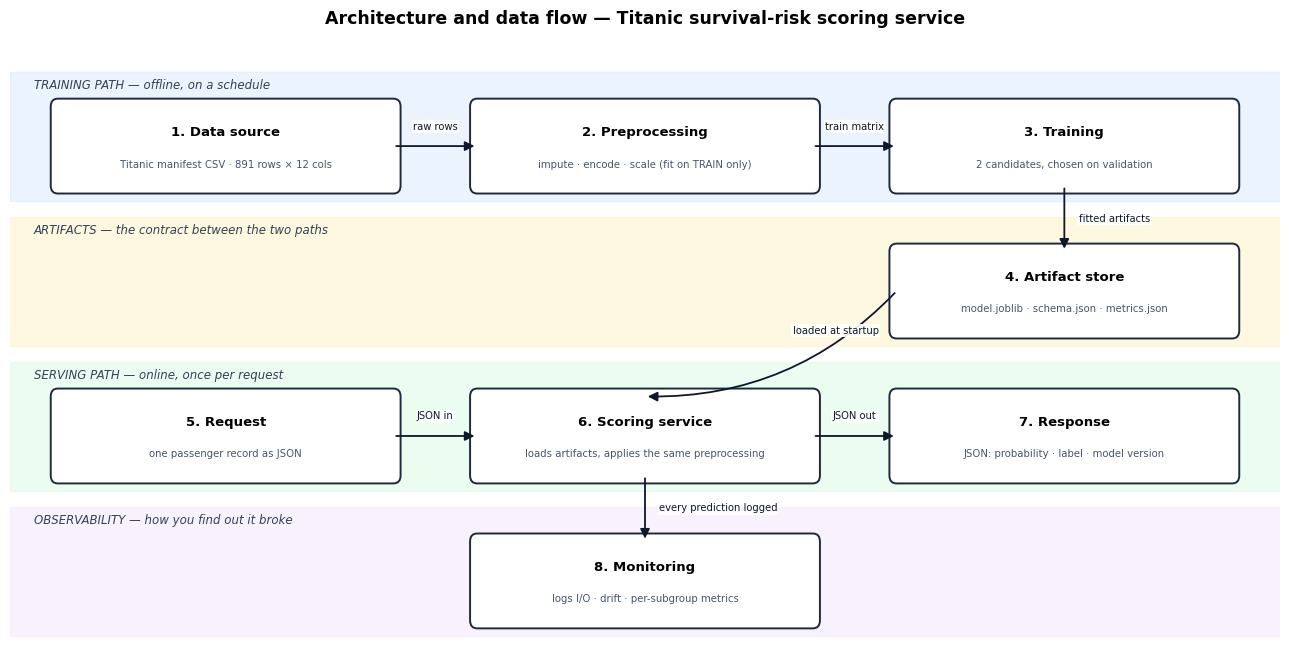

Diagram drawn: 8 components, 7 flows.
Check 1 — every arrow endpoint is a declared component: PASS
Check 2 — components appearing in no flow: none (PASS)


In [3]:
# Draw the architecture and data-flow diagram FROM the component registry, so the picture and
# the design cannot drift apart. WHY a function and not a hand-drawn image: at the design
# review your diagram is checked against your data_flow string; generating one from the other
# makes that check pass by construction, and makes the diagram cheap to redraw when the design
# changes (it will change).

# Lane -> (vertical position, banner text, band colour). Lanes encode WHEN code runs.
LANES = {
    "train": (3.3, "TRAINING PATH — offline, on a schedule", "#dbeafe"),
    "store": (2.2, "ARTIFACTS — the contract between the two paths", "#fef3c7"),
    "serve": (1.1, "SERVING PATH — online, once per request", "#dcfce7"),
    "mon":   (0.0, "OBSERVABILITY — how you find out it broke", "#f3e8ff"),
}


def draw_architecture(components, flows, title, outfile=None):
    """Render components+flows as a lane diagram, refusing to draw an inconsistent design."""
    ids = [c["id"] for c in components]

    # Consistency rule 1: an arrow may not point at something that is not a component
    unknown = sorted({end for a, b, _ in flows for end in (a, b) if end not in ids})
    if unknown:
        raise ValueError(
            f"data flow names components that were never declared: {unknown}. "
            "Add them to the component registry, or remove the arrow."
        )
    # Consistency rule 2: a component with no arrows is dead weight (a warning, not an error)
    orphans = sorted(set(ids) - {end for a, b, _ in flows for end in (a, b)})

    pos, W, H = {}, 2.8, 0.60
    fig, ax = plt.subplots(figsize=(13, 6.8))

    for lane, (y, label, colour) in LANES.items():
        ax.axhspan(y - 0.42, y + 0.56, color=colour, alpha=0.55, zorder=0)
        ax.text(-1.6, y + 0.46, label, fontsize=8.5, style="italic",
                color="#334155", ha="left", va="center", zorder=2)

    # One rounded box per component: bold name on top, its one-line job underneath
    for c in components:
        y = LANES[c["lane"]][0]
        x = c["col"] * 3.5
        pos[c["id"]] = (x, y)
        ax.add_patch(FancyBboxPatch((x - W / 2, y - H / 2), W, H, boxstyle="round,pad=0.06",
                                    fc="white", ec="#1e293b", lw=1.4, zorder=3))
        ax.text(x, y + 0.10, c["name"], ha="center", va="center",
                fontsize=9.5, fontweight="bold", zorder=4)
        ax.text(x, y - 0.14, c["does"], ha="center", va="center",
                fontsize=7.3, color="#475569", zorder=4)

    # One arrow per flow; the label on the arrow is WHAT travels along it, not a verb
    for a, b, label in flows:
        (xa, ya), (xb, yb) = pos[a], pos[b]
        if ya == yb:                                   # same lane -> straight, left to right
            start, end, rad = (xa + W / 2, ya), (xb - W / 2, yb), 0.0
            lx, ly, ha_, va_ = (start[0] + end[0]) / 2, ya + 0.11, "center", "bottom"
        elif xa == xb:                                 # lane change, same column -> vertical
            start, end, rad = (xa, ya - H / 2), (xb, yb + H / 2), 0.0
            lx, ly, ha_, va_ = xa + 0.12, (start[1] + end[1]) / 2, "left", "center"
        else:                                          # lane change + column change -> curve
            # Leave from the SIDE that faces the target, not from the bottom: a curve that starts
            # underneath the box swings back through it and draws a line that means nothing.
            side = -1 if xb < xa else 1
            start, end, rad = (xa + side * W / 2, ya), (xb, yb + H / 2), 0.22 * side
            lx, ly, ha_, va_ = (xa + side * (W / 2 + 0.15), ya - 0.30,
                                "right" if side < 0 else "left", "center")
        ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=14, lw=1.3,
                                     color="#0f172a", connectionstyle=f"arc3,rad={rad}", zorder=5))
        ax.text(lx, ly, label, fontsize=7.2, ha=ha_, va=va_, color="#0f172a",
                bbox=dict(fc="white", ec="none", alpha=0.9, pad=1.0), zorder=6)

    ax.set_xlim(-1.8, 8.8)
    ax.set_ylim(-0.6, 4.1)
    ax.axis("off")
    ax.set_title(title, fontsize=12.5, fontweight="bold", pad=12)
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=110, bbox_inches="tight")
    plt.show()

    print(f"Diagram drawn: {len(components)} components, {len(flows)} flows.")
    print("Check 1 — every arrow endpoint is a declared component: PASS")
    print(f"Check 2 — components appearing in no flow: {orphans if orphans else 'none (PASS)'}")


# The data flow: (from, to, what travels). Read it aloud and it is the system's story.
FLOWS = [
    ("source", "prep", "raw rows"),
    ("prep", "train", "train matrix"),
    ("train", "store", "fitted artifacts"),
    ("store", "serve", "loaded at startup"),
    ("request", "serve", "JSON in"),
    ("serve", "response", "JSON out"),
    ("serve", "monitor", "every prediction logged"),
]

draw_architecture(COMPONENTS, FLOWS,
                  "Architecture and data flow — Titanic survival-risk scoring service")

In [4]:
# Prove that the consistency rule is real, not decoration: add one arrow that points at a
# component nobody declared and the drawing function refuses. WHY show the failure: at the
# design review, "the diagram has a cache that is not in the component list" is a standard
# deduction, and this is the check that catches it before the reviewer does.
try:
    draw_architecture(COMPONENTS, FLOWS + [("redis_cache", "serve", "cached scores")],
                      "This design should not render")
except ValueError as err:
    print("Refused to draw, correctly:")
    print(f"  {err}")

Refused to draw, correctly:
  data flow names components that were never declared: ['redis_cache']. Add them to the component registry, or remove the arrow.


**Reading the diagram.** Three things a reviewer looks for, all visible above:

1. **Where does one new input enter, and what touches it, in order?** Follow *5. Request →
   6. Scoring service → 7. Response*. If you cannot trace a single record through your own
   diagram in one breath, the design is not finished.
2. **Where is the preprocessing fitted?** Inside the *training* lane, on the training split
   only — and it leaves as an artifact. The serving lane *loads* it; it never refits. Fitting a
   scaler or an encoder on the whole dataset before the split is the leakage error Unit 3
   teaches against, and it is cheapest to catch here, on paper.
3. **What connects the two paths?** The artifact store, and nothing else. That is what makes
   the training path replaceable without touching the service.

**Your turn later:** in Part 8 you will pass *your* components and *your* flows to
`draw_architecture(...)`. If it raises, your design is inconsistent — that is the function
doing its job.

---

## Part 3 — Selecting the model, the algorithm, the dataset and the platform

The official unit asks for four selections, each **with justification**. A justification is
not "it performs well". A justification names *your* data type, *your* data size, and *your*
constraints, and it names what you rejected and why.

### A decision matrix makes the argument reviewable

Score each candidate 1–5 against criteria you weight in advance. The matrix does not make the
decision for you — it makes the decision **arguable**: a reviewer can attack a weight or a
score, which is a far more productive conversation than attacking a preference.

**Do not reward complexity.** In this course a *justified* logistic regression scores full
marks and an *unjustified* transformer does not. The matrix below is set up for the worked
example's real constraints: 891 rows, 7 usable features, a decision that a human may have to
explain to the person it affects.

In [5]:
# Weighted decision matrix for model selection. WHY weights first, scores second: if you pick
# the weights after seeing the scores you will simply justify the model you already wanted.
# Weights must sum to 1.0 and each one has to be defensible from the PROPOSAL, not invented here.
CRITERIA_WEIGHTS = {
    "fits the data type/size (891 rows, tabular)": 0.30,
    "interpretable to an affected person":         0.25,
    "training cost within the course budget":      0.15,
    "inference latency for a per-request API":     0.15,
    "team already has the skill (AIAT 114)":       0.15,
}

# Scores are 1 (poor) .. 5 (excellent) for THIS project. Change the project, change the scores.
CANDIDATE_SCORES = {
    "Logistic regression":        [4, 5, 5, 5, 5],
    "Decision tree (depth 4)":    [5, 5, 5, 5, 4],
    "Random forest (200 trees)":  [5, 2, 4, 4, 4],
    "Fine-tuned transformer":     [1, 1, 1, 2, 2],
}

weights = np.array(list(CRITERIA_WEIGHTS.values()))
matrix = pd.DataFrame(CANDIDATE_SCORES, index=list(CRITERIA_WEIGHTS)).T
matrix.columns = [f"{c}\n(w={w:.2f})" for c, w in CRITERIA_WEIGHTS.items()]
matrix["WEIGHTED TOTAL"] = (matrix.values * weights).sum(axis=1).round(2)

print("=" * 96)
print("MODEL SELECTION MATRIX — scores 1..5, weights fixed before scoring")
print("=" * 96)
print(matrix.to_string())
winner = matrix["WEIGHTED TOTAL"].idxmax()
runner_up = matrix["WEIGHTED TOTAL"].drop(index=winner).idxmax()
print(f"\nHighest weighted total: {winner} "
      f"({matrix.loc[winner, 'WEIGHTED TOTAL']:.2f} / 5.00)")
print(f"Runner-up:              {runner_up} "
      f"({matrix.loc[runner_up, 'WEIGHTED TOTAL']:.2f} / 5.00)")
print("\nThe top two are close, and 'close' is the honest answer at design time.")
print("A matrix is an ARGUMENT, not a verdict. Part 3b measures whether the argument holds.")

MODEL SELECTION MATRIX — scores 1..5, weights fixed before scoring
                           fits the data type/size (891 rows, tabular)\n(w=0.30)  interpretable to an affected person\n(w=0.25)  training cost within the course budget\n(w=0.15)  inference latency for a per-request API\n(w=0.15)  team already has the skill (AIAT 114)\n(w=0.15)  WEIGHTED TOTAL
Logistic regression                                                            4                                              5                                                 5                                                  5                                                5            4.70
Decision tree (depth 4)                                                        5                                              5                                                 5                                                  5                                                4            4.85
Random forest (200 trees)                          

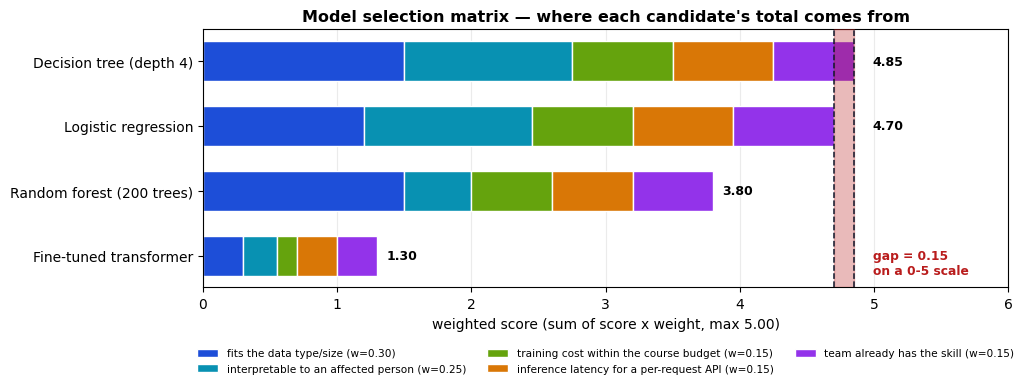

Top two: Decision tree (depth 4) 4.85 vs Logistic regression 4.70 -> gap 0.15 of 5.00 (3% of the scale).
Lowest: Fine-tuned transformer at 1.30.


In [6]:
# See the matrix instead of reading it. Each bar is one candidate, split into the five weighted
# contributions (score x weight) that add up to its total. WHY draw it: the printed table hides
# how CLOSE the top two are, and "close" is the finding — a 0.15 gap on a 5-point scale is not a
# decision, it is a tie that the measurement in Part 3b has to break.
contributions = matrix.drop(columns="WEIGHTED TOTAL") * weights   # per-criterion contribution
order = matrix["WEIGHTED TOTAL"].sort_values().index              # smallest bar at the bottom
short_labels = [c.split("\n")[0].split(" (")[0] for c in contributions.columns]
segment_colours = ["#1d4ed8", "#0891b2", "#65a30d", "#d97706", "#9333ea"]

fig, ax = plt.subplots(figsize=(10.6, 4.3))
left = np.zeros(len(order))
for j, colour in enumerate(segment_colours):
    values = contributions.loc[order].iloc[:, j].to_numpy()
    ax.barh(list(order), values, left=left, height=0.62, color=colour, edgecolor="white",
            zorder=2, label=f"{short_labels[j]} (w={weights[j]:.2f})")
    left = left + values

# The two dashed lines are the top two totals. If you cannot tell them apart, that IS the result.
top_total = matrix.loc[winner, "WEIGHTED TOTAL"]
second_total = matrix.loc[runner_up, "WEIGHTED TOTAL"]
ax.axvspan(second_total, top_total, color="#b91c1c", alpha=0.30, zorder=3)
for total in (top_total, second_total):
    ax.axvline(total, color="#0f172a", ls="--", lw=1.1, zorder=4)
ax.text(top_total + 0.14, 0.04, f"gap = {top_total - second_total:.2f}\non a 0-5 scale",
        transform=ax.get_xaxis_transform(), fontsize=8.8, va="bottom", ha="left", color="#b91c1c",
        fontweight="bold")

for candidate in order:
    total = matrix.loc[candidate, "WEIGHTED TOTAL"]
    # Keep the top-two labels OUT of the shaded gap band, otherwise "4.70" is printed on top of
    # the very band the figure is asking you to look at.
    label_x = total + 0.07 if total < second_total else top_total + 0.14
    ax.text(label_x, candidate, f"{total:.2f}", va="center", fontsize=9, fontweight="bold")

ax.set_xlim(0, 6.0)
ax.set_xlabel("weighted score (sum of score x weight, max 5.00)")
ax.set_title("Model selection matrix — where each candidate's total comes from", fontsize=11.5,
             fontweight="bold")
ax.legend(fontsize=7.6, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.20), frameon=False)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
fig.subplots_adjust(left=0.215, right=0.975, top=0.90, bottom=0.30)
plt.show()

print(f"Top two: {winner} {top_total:.2f} vs {runner_up} {second_total:.2f} "
      f"-> gap {top_total - second_total:.2f} of 5.00 ({(top_total - second_total) / 5 * 100:.0f}% of the scale).")
print(f"Lowest: {matrix['WEIGHTED TOTAL'].idxmin()} at {matrix['WEIGHTED TOTAL'].min():.2f}.")


**Reading the figure.** The two dashed vertical lines are the top two totals — **4.85** and
**4.70** — and they are almost on top of each other. That near-overlap is the honest reading of
this matrix: it did **not** choose a model.

Follow the coloured segments and you can see exactly where the tree's lead comes from: it wins
the first criterion (*fits the data type/size*, 1.50 against the logistic regression's 1.20) and
loses the last (*team already has the skill*, 0.60 against 0.75). Net: +0.15, the whole gap. One
argued score on one criterion would flip the ranking — which is why a matrix is an argument you
can attack, not a verdict.

The one clear signal in the picture is the bottom bar: the **fine-tuned transformer at 1.30**,
barely a quarter of the winner's length, because every criterion that matters here penalises it.
Complexity is not rewarded; it is charged for.


### Part 3b — Back the justification with a measurement

A design review question you should expect: *"you say a linear model is enough for your data —
how do you know?"* At design time you cannot know the final answer, but you can afford a
**one-minute check** on the real data, and a design that includes one is much harder to argue
with.

Below: the real Titanic manifest, split 60/20/20 (stratified), two candidate models fitted on
the training split and compared on **validation**. The test split is created and then left
completely alone — it gets measured once, at gate 4, and never during design.

In [7]:
# Load the real manifest and build the design-time evidence split. WHY stratify: the target is
# imbalanced (fewer survivors than non-survivors), and an unstratified split can hand the
# validation set a different class ratio than the training set, which makes every comparison
# below meaningless.
raw = pd.read_csv(TITANIC)

NUMERIC_FEATURES = ["Age", "Fare", "SibSp", "Parch", "Pclass"]
CATEGORICAL_FEATURES = ["Sex", "Embarked"]
TARGET = "Survived"

# Cabin (77.1% missing) and the free-text Name/Ticket columns are deliberately EXCLUDED here —
# that exclusion is itself a design decision and it goes in the data plan in Part 4.
design_df = raw[NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]].copy()
X = design_df.drop(columns=[TARGET])
y = design_df[TARGET]

# 60 / 20 / 20: carve off the test set first so it can never be touched by a design decision
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_tmp)

print(f"Dataset: {raw.shape[0]} rows × {raw.shape[1]} columns")
print(f"Split   -> train {len(X_train)} | validation {len(X_val)} | test {len(X_test)} (untouched)")
print(f"Survival rate: train {y_train.mean():.3f} | validation {y_val.mean():.3f}")

# The preprocessing component from the registry, as real code: median-impute numerics,
# mode-impute + one-hot the categoricals, scale. It is FITTED INSIDE the pipeline, so it is
# only ever fitted on the training rows — the leakage rule from the diagram, enforced in code.
preprocessing = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC_FEATURES),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL_FEATURES),
])

candidates = {
    "Logistic regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision tree (depth 4)": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
}

evidence = {}
fitted = {}
for name, estimator in candidates.items():
    pipe = Pipeline([("prep", preprocessing), ("model", estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    fitted[name] = pipe
    evidence[name] = {
        "accuracy": round(accuracy_score(y_val, pred), 4),
        "precision": round(precision_score(y_val, pred), 4),
        "recall": round(recall_score(y_val, pred), 4),
        "f1": round(f1_score(y_val, pred), 4),
    }

print("\n" + "=" * 96)
print("DESIGN-TIME EVIDENCE — validation split only, test split untouched")
print("=" * 96)
print(pd.DataFrame(evidence).T.to_string())

Dataset: 891 rows × 12 columns
Split   -> train 534 | validation 178 | test 179 (untouched)
Survival rate: train 0.384 | validation 0.382

DESIGN-TIME EVIDENCE — validation split only, test split untouched
                         accuracy  precision  recall      f1
Logistic regression        0.8034     0.7619  0.7059  0.7328
Decision tree (depth 4)    0.8146     0.8302  0.6471  0.7273


**Reading the evidence — and why it is not yet a decision.**

The matrix and the measurement do not agree cleanly, and that is the useful part:

- The **decision tree** takes the higher **accuracy**.
- The **logistic regression** takes the higher **F1**.

You cannot read that table until you have said which number the project is graded on. That is
the whole argument for Part 5: **choose the metric and the baseline before you compare models**,
otherwise you will pick the metric that flatters the model you already liked. Write the metric
into the design document, and the comparison becomes a fact instead of a preference.

Note also what the measurement cost: seconds. A one-minute check at design time is the cheapest
evidence you will ever produce in this project.

---

## Part 4 — Planning data collection and preprocessing

Your proposal named a dataset. The design has to say what you will *do* to it, column by
column. The mistake to avoid is writing a generic plan ("handle missing values, encode
categoricals") that would fit any dataset on earth — which means it fits yours only by
accident.

**The plan is derived from a profile of the real data.** Below, the profile is computed and
the plan rows are generated from it, using rules a reviewer can argue with:

| Condition on the real column | Planned action |
|---|---|
| > 40% missing | drop the column, and say so — imputing three quarters of a column invents data |
| numeric, some missing | median impute (robust to the skew real money/age columns have) |
| categorical, some missing | most-frequent impute |
| free text / near-unique (`n_unique` ≈ `n_rows`) | out of scope for this design, or a separate NLP component (AIAT 121) |
| categorical with more than 20 levels | group the levels or exclude the column — one-hot encoding it would add more columns than the rows can support |
| the target | never impute; drop rows with a missing target |

In [8]:
# Profile the REAL columns, then generate the preprocessing plan FROM the profile. WHY generate
# rather than write: a hand-written plan drifts from the data the moment the data changes, and a
# reviewer cannot tell whether you looked at the file or at a template.
profile = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_%": (raw.isna().mean() * 100).round(1),
    "n_unique": raw.nunique(),
})
profile["unique_ratio"] = (profile["n_unique"] / len(raw)).round(3)

print("=" * 96)
print(f"COLUMN PROFILE — {TITANIC.name}, {len(raw)} rows")
print("=" * 96)
print(profile.to_string())


def plan_for(column, row, n_rows, target):
    """Turn one profiled column into one planned action, with the reason attached."""
    if column == target:
        return "keep as target", "never imputed; rows with a missing target are dropped"
    if row["missing_%"] > 40:
        return "DROP", f"{row['missing_%']}% missing — imputing this would be inventing data"
    if row["unique_ratio"] > 0.9 and row["dtype"] == "object":
        return "OUT OF SCOPE (or separate text component)", \
               f"{row['n_unique']} distinct values in {n_rows} rows — free text, not a category"
    if row["unique_ratio"] > 0.9:
        return "DROP (identifier)", "unique per row — an ID carries no signal, only leakage risk"
    if row["dtype"] == "object" and row["n_unique"] > 20:
        return "GROUP or EXCLUDE (high cardinality)", \
               (f"{row['n_unique']} categories for {n_rows} rows — one-hot would add more "
                f"columns than the data can support")
    if row["dtype"] == "object":
        action = "most-frequent impute + one-hot encode" if row["missing"] else "one-hot encode"
        return action, f"{row['n_unique']} categories, {row['missing']} missing"
    action = "median impute + standard-scale" if row["missing"] else "standard-scale"
    return action, f"numeric, {row['missing']} missing ({row['missing_%']}%)"


plan_rows = []
for column, row in profile.iterrows():
    action, reason = plan_for(column, row, len(raw), TARGET)
    plan_rows.append({"column": column, "planned action": action, "reason (from the profile)": reason})

data_plan = pd.DataFrame(plan_rows)
print("\n" + "=" * 96)
print("DATA COLLECTION & PREPROCESSING PLAN — generated from the profile above")
print("=" * 96)
print(data_plan.to_string(index=False))

print("\nEvery action above is fitted on the TRAINING split only and saved as an artifact,")
print("exactly as the diagram in Part 2 requires.")

COLUMN PROFILE — titanic.csv, 891 rows
               dtype  missing  missing_%  n_unique  unique_ratio
PassengerId    int64        0        0.0       891         1.000
Survived       int64        0        0.0         2         0.002
Pclass         int64        0        0.0         3         0.003
Name          object        0        0.0       891         1.000
Sex           object        0        0.0         2         0.002
Age          float64      177       19.9        88         0.099
SibSp          int64        0        0.0         7         0.008
Parch          int64        0        0.0         7         0.008
Ticket        object        0        0.0       681         0.764
Fare         float64        0        0.0       248         0.278
Cabin         object      687       77.1       147         0.165
Embarked      object        2        0.2         3         0.003

DATA COLLECTION & PREPROCESSING PLAN — generated from the profile above
     column                            plan

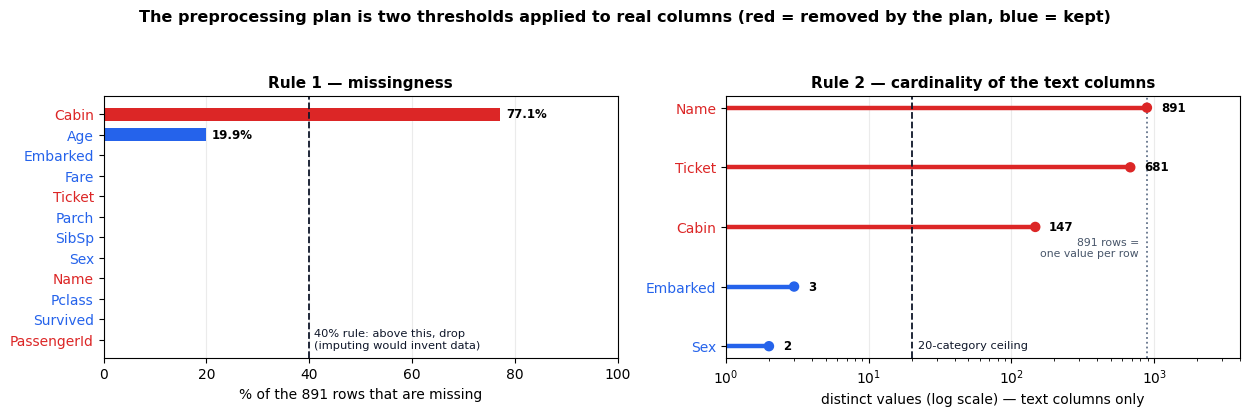

Columns removed by the plan: Cabin, Name, PassengerId, Ticket
Columns kept: Age, Embarked, Fare, Parch, Pclass, Sex, SibSp, Survived


In [9]:
# Draw the two THRESHOLDS the plan applied, against the real columns. WHY: the table above states
# each decision, but the picture shows the rule that produced it — and a threshold you can see is
# a threshold a reviewer can argue with, which is the whole point of generating the plan.
actions = data_plan.set_index("column")["planned action"]
removed = actions.str.startswith(("DROP", "OUT OF SCOPE", "GROUP"))   # columns the plan removes
KEEP_C, DROP_C = "#2563eb", "#dc2626"

fig, (ax_missing, ax_card) = plt.subplots(1, 2, figsize=(12.6, 4.2))

# Left: the ">40% missing -> drop" rule, against every real column
miss = profile["missing_%"].sort_values()
ax_missing.barh(list(miss.index), miss.to_numpy(), height=0.65,
                color=[DROP_C if removed[c] else KEEP_C for c in miss.index])
ax_missing.axvline(40, color="#0f172a", ls="--", lw=1.3)
ax_missing.text(41, 0.03, "40% rule: above this, drop\n(imputing would invent data)",
                transform=ax_missing.get_xaxis_transform(),
                fontsize=8.2, color="#0f172a", va="bottom")
for column in ("Cabin", "Age"):
    ax_missing.text(profile.loc[column, "missing_%"] + 1.2, list(miss.index).index(column),
                    f"{profile.loc[column, 'missing_%']}%", va="center", fontsize=8.5,
                    fontweight="bold")
ax_missing.set_xlim(0, 100)
ax_missing.set_xlabel("% of the 891 rows that are missing")
ax_missing.set_title("Rule 1 — missingness", fontsize=11, fontweight="bold")
ax_missing.grid(axis="x", alpha=0.25)
ax_missing.set_axisbelow(True)

# Right: the "more than 20 categories -> group or exclude" rule, for the OBJECT columns only
object_columns = profile.index[profile["dtype"] == "object"]
card = profile.loc[object_columns, "n_unique"].sort_values()
ax_card.hlines(list(card.index), 1, card.to_numpy(),
               color=[DROP_C if removed[c] else KEEP_C for c in card.index], lw=3.2)
ax_card.scatter(card.to_numpy(), list(card.index),
                color=[DROP_C if removed[c] else KEEP_C for c in card.index], s=42, zorder=3)
for column, value in card.items():
    ax_card.text(value * 1.25, column, f"{value}", va="center", fontsize=8.5, fontweight="bold")
ax_card.axvline(20, color="#0f172a", ls="--", lw=1.3)
ax_card.axvline(len(raw), color="#64748b", ls=":", lw=1.3)
ax_card.text(22, 0.03, "20-category ceiling", transform=ax_card.get_xaxis_transform(),
             fontsize=8.2, color="#0f172a", va="bottom")
ax_card.text(len(raw) * 0.88, 0.42, f"{len(raw)} rows =\none value per row",
             transform=ax_card.get_xaxis_transform(),
             fontsize=7.8, color="#475569", ha="right", va="center")

# Colour the tick labels as well: a column with 0% missing has no visible bar, and its
# keep/remove status would otherwise be invisible in the left panel.
for axis, names in ((ax_missing, miss.index), (ax_card, card.index)):
    for tick_label, column in zip(axis.get_yticklabels(), names):
        tick_label.set_color(DROP_C if removed[column] else KEEP_C)
ax_card.set_xscale("log")
ax_card.set_xlim(1, 4000)
ax_card.set_xlabel("distinct values (log scale) — text columns only")
ax_card.set_title("Rule 2 — cardinality of the text columns", fontsize=11, fontweight="bold")
ax_card.grid(axis="x", alpha=0.25)
ax_card.set_axisbelow(True)

fig.suptitle("The preprocessing plan is two thresholds applied to real columns "
             "(red = removed by the plan, blue = kept)", fontsize=11.5, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

print(f"Columns removed by the plan: {', '.join(sorted(actions.index[removed]))}")
print(f"Columns kept: {', '.join(sorted(actions.index[~removed]))}")


**Reading the figure.** *Left:* exactly one bar crosses the 40% line — **`Cabin` at 77.1%**. The
next-largest gap, **`Age` at 19.9%**, sits well inside the line, which is why the plan imputes it
instead of throwing away 177 passengers. Everything else sits at or near zero: this dataset's
missingness problem is two columns (plus two stray rows in `Embarked`), not twelve, and you can
see that in one glance.

*Right:* the text columns split cleanly around the 20-category ceiling. **`Name` (891)** and
**`Ticket` (681)** sit far past it — `Name` lands exactly on the grey "one value per row" line,
which is the definition of free text — while **`Sex` (2)** and **`Embarked` (3)** sit far below it
and one-hot encode safely. `Cabin` (147) is past the ceiling too, but the left-hand rule had
already removed it.

Red marks the four columns the plan removes — `Cabin`, `Name`, `Ticket`, `PassengerId` — in the
bars *and* in the axis labels, which is how you can see that three of them have no missingness at
all and were removed by the other rules. Nothing here was dropped by preference: **every red label
is red because the column crossed a line drawn before the file was opened.**


**What the generated plan just told us, that a template never would:**

- `Cabin` is **77.1% missing** — the rule drops it. A design that promised to "impute missing
  cabins" would have been promising to invent 687 values.
- `Age` is **19.9% missing** — real, substantial, and worth imputing rather than dropping 177
  passengers.
- `PassengerId` is **unique per row** — an identifier. Dropping it is a *leakage* decision, not a
  tidiness one: an ID that correlates with the target teaches the model nothing transferable.
- `Name` is **891 distinct values in 891 rows** — free text, not a category. If your project wants
  the titles inside it (*Mr*, *Mrs*, *Master*), that is a **separate text-processing component**
  reusing AIAT 121, and it belongs in the component registry, not hidden in a preprocessing step.
- `Ticket` has **681 categories in 891 rows**. One-hot encoding it would produce 681 columns from
  891 examples — more columns than the data can support. The rule says group or exclude, and this
  is exactly the kind of decision that is invisible until you profile the file.

**Collection planning, in one line each, for your own design document:** where the data comes
from, how often it refreshes, what the licence permits, how much you can legally keep, and who
you ask when it breaks. If any of those five is unknown, that is a risk for Part 8, not a gap to
paper over.

---

## Part 5 — Evaluation metrics and baselines

Two decisions, both made **before** training, both written into the design document:

1. **The primary metric**, and why it is the right one for the harm you are trying to avoid.
2. **The baselines you must beat** — and a baseline is not "the last paper's number". It is
   something you can compute today, on your own data.

Two baselines are worth computing for almost every project:

- **The majority-class baseline.** Predict the most common class for everything. This is the
  number that exposes accuracy as a metric: on an imbalanced dataset it can look excellent while
  the model has learned nothing.
- **The simplest defensible domain rule.** One line of if/else that a domain expert would write
  without any machine learning. If your model cannot beat it, the ML is not earning its
  complexity — and finding that out at design time saves you the whole project.

For the worked example the domain rule writes itself from the historical record: **"women and
children first"**. Below, its simplest form — *predict survived if female* — is measured on the
same validation split as the models.

In [10]:
# Compute the two baselines on the SAME validation split the models were scored on. WHY the same
# split: a baseline measured on different rows is not a comparison, it is a coincidence.


def score(y_true, y_pred, label):
    """One row of the comparison table — the same four metrics for every candidate."""
    return {
        "candidate": label,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
    }


# Baseline 1: predict the majority class of the TRAINING split for every validation row
majority_class = int(y_train.mode()[0])
pred_majority = np.full(len(y_val), majority_class, dtype=int)

# Baseline 2: the historical domain rule, "women and children first", in its simplest form
pred_rule = (X_val["Sex"] == "female").astype(int).to_numpy()

rows = [
    score(y_val, pred_majority, f"BASELINE 0 — always predict {majority_class}"),
    score(y_val, pred_rule, "BASELINE 1 — domain rule: female -> survived"),
]
for name, pipe in fitted.items():
    rows.append(score(y_val, pipe.predict(X_val), f"MODEL — {name}"))

comparison = pd.DataFrame(rows).set_index("candidate")
print("=" * 96)
print("METRICS AND BASELINES — validation split, before any tuning")
print("=" * 96)
print(comparison.to_string())

# State the "must beat" threshold explicitly: it goes into the design document verbatim
must_beat_f1 = comparison.loc["BASELINE 1 — domain rule: female -> survived", "f1"]
must_beat_acc = comparison.loc["BASELINE 1 — domain rule: female -> survived", "accuracy"]
print(f"\nMUST BEAT (from the domain rule): F1 > {must_beat_f1}  and  accuracy > {must_beat_acc}")
for name in fitted:
    row = comparison.loc[f"MODEL — {name}"]
    verdict = "clears it" if row["f1"] > must_beat_f1 else "does NOT clear it"
    print(f"  {name:<26} F1 {row['f1']:.4f} -> {verdict}")

# The fairness fact behind the rule's strength — this is a design input, not trivia
by_sex = raw.groupby("Sex")[TARGET].agg(["mean", "size"]).round(4)
print("\nWhy the rule is so strong (full dataset):")
print(by_sex.rename(columns={"mean": "survival rate", "size": "passengers"}).to_string())


METRICS AND BASELINES — validation split, before any tuning
                                              accuracy  precision  recall      f1
candidate                                                                        
BASELINE 0 — always predict 0                   0.6180     0.0000  0.0000  0.0000
BASELINE 1 — domain rule: female -> survived    0.8034     0.7538  0.7206  0.7368
MODEL — Logistic regression                     0.8034     0.7619  0.7059  0.7328
MODEL — Decision tree (depth 4)                 0.8146     0.8302  0.6471  0.7273

MUST BEAT (from the domain rule): F1 > 0.7368  and  accuracy > 0.8034
  Logistic regression        F1 0.7328 -> does NOT clear it
  Decision tree (depth 4)    F1 0.7273 -> does NOT clear it



Why the rule is so strong (full dataset):
        survival rate  passengers
Sex                              
female         0.7420         314
male           0.1889         577


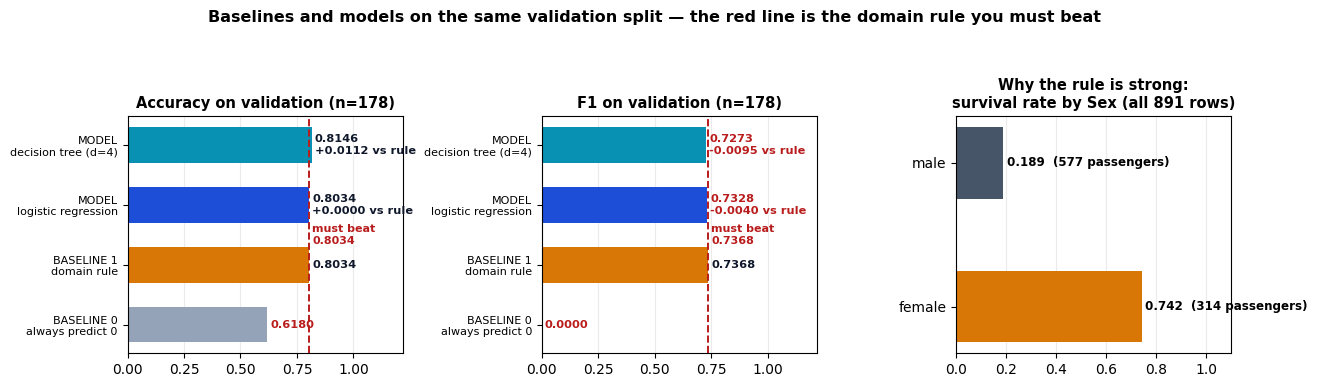

Logistic regression        F1 0.7328 vs rule 0.7368 -> BELOW the red line
Decision tree (depth 4)    F1 0.7273 vs rule 0.7368 -> BELOW the red line


In [11]:
# The punchline of Part 5 as a picture: the trained models against the one-line domain rule, on
# the same validation split, plus the subgroup fact that explains why the rule is so strong.
# WHY plot it: "the model does not beat the if-statement" is the single most important sentence in
# this design review, and a table of four rows lets a reader skim past it.
SHORT = {f"BASELINE 0 — always predict {majority_class}": f"BASELINE 0\nalways predict {majority_class}",
         "BASELINE 1 — domain rule: female -> survived": "BASELINE 1\ndomain rule",
         "MODEL — Logistic regression": "MODEL\nlogistic regression",
         "MODEL — Decision tree (depth 4)": "MODEL\ndecision tree (d=4)"}
labels = [SHORT[i] for i in comparison.index]
bar_colours = ["#94a3b8", "#d97706", "#1d4ed8", "#0891b2"]   # baselines warm/grey, models blue

fig, (ax_acc, ax_f1, ax_sex) = plt.subplots(1, 3, figsize=(13.2, 3.9))

for ax, metric, must_beat, title in (
        (ax_acc, "accuracy", must_beat_acc, "Accuracy on validation (n=%d)" % len(y_val)),
        (ax_f1, "f1", must_beat_f1, "F1 on validation (n=%d)" % len(y_val))):
    values = comparison[metric].to_numpy()
    ax.barh(labels, values, height=0.6, color=bar_colours)
    ax.axvline(must_beat, color="#b91c1c", ls="--", lw=1.4)
    ax.text(must_beat + 0.015, 0.50, f"must beat\n{must_beat:.4f}", fontsize=8.0, color="#b91c1c",
            transform=ax.get_xaxis_transform(), va="center", fontweight="bold")
    for y_index, (candidate, value) in enumerate(zip(comparison.index, values)):
        delta = value - must_beat
        # The bars are near-identical at this scale; the signed gap to the rule is the point
        suffix = f"\n{delta:+.4f} vs rule" if candidate.startswith("MODEL") else ""
        ax.text(value + 0.014, y_index, f"{value:.4f}{suffix}", va="center", fontsize=8.2,
                fontweight="bold", color="#0f172a" if delta >= 0 else "#b91c1c")
    ax.set_xlim(0, 1.22)
    ax.set_title(title, fontsize=10.5, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8.0)
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)

# Third panel: the subgroup disparity the domain rule is exploiting — a design input, not trivia
rates = by_sex["mean"]
ax_sex.barh(list(rates.index), rates.to_numpy(), height=0.5, color=["#d97706", "#475569"])
for y_index, (group, rate) in enumerate(rates.items()):
    ax_sex.text(rate + 0.015, y_index, f"{rate:.3f}  ({int(by_sex.loc[group, 'size'])} passengers)",
                va="center", fontsize=8.6, fontweight="bold")
ax_sex.set_xlim(0, 1.10)
ax_sex.set_title("Why the rule is strong:\nsurvival rate by Sex (all 891 rows)", fontsize=10.5,
                 fontweight="bold")
ax_sex.grid(axis="x", alpha=0.25)
ax_sex.set_axisbelow(True)

fig.suptitle("Baselines and models on the same validation split — the red line is the "
             "domain rule you must beat", fontsize=11.5, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

for name in fitted:
    row = comparison.loc[f"MODEL — {name}"]
    print(f"{name:<26} F1 {row['f1']:.4f} vs rule {must_beat_f1:.4f} "
          f"-> {'clears' if row['f1'] > must_beat_f1 else 'BELOW the red line'}")


**Reading the figure.** In the **F1** panel (middle) the three non-zero bars are the same length
to the eye — and that *is* the result. The red "must beat" line sits to the *right* of both model bars
(blue = logistic regression, teal = decision tree), and the signed gaps printed beside them say it in red: the logistic regression is
**0.0040 short** of the rule and the decision tree **0.0095 short**. Two trained models, both
behind one line of if/else. In the **accuracy** panel (left) the logistic regression bar ends
exactly on the line (0.8034 both) and only the tree pokes past it (+0.0112). Whether the ML "wins"
depends entirely on which panel you agreed to look at — before you looked.

The bar to watch in the accuracy panel is the bottom one: **BASELINE 0 reaches 0.6180 accuracy while
its F1 bar has no visible length at all** (0.0000). A model that never finds a single survivor
still scores 62% accuracy here. That is the whole argument for choosing the metric in the design.

The right panel says where the rule's strength comes from: **74.2% of the 314 women survived and
18.9% of the 577 men**. The competitor your model has to beat is one protected attribute — carry
that straight into the risks section.


### The uncomfortable result, and what a designer does with it

On this validation split the one-line domain rule scores **accuracy 0.8034, F1 0.7368**. The
logistic regression scores **accuracy 0.8034, F1 0.7328** — it *ties* the rule on accuracy and
*loses* to it on F1. The decision tree reaches a higher accuracy (**0.8146**) but a lower F1
(**0.7273**) than the rule.

**Both** trained models fail to beat one line of if/else on F1. That is not a failure of the
notebook; it is the reason baselines belong in the **design**, before you have spent three weeks
building. A design review that produces this table asks the right questions immediately:

1. **Is the extra feature set earning anything?** If the model is essentially rediscovering
   `Sex`, the honest design either adds features that carry independent signal, or admits the
   rule is the right product and the project's contribution is elsewhere.
2. **Is accuracy even the metric?** On a 61.8% majority-class split, "always predict 0" already
   scores **0.6180 accuracy with an F1 of 0.0** — it never identifies a single survivor. If
   finding survivors is the point, F1 or recall is the primary metric, and the design must say so.
3. **Is the strongest predictor one you are allowed to use?** The rule works because survival
   was **74.2% for women and 18.9% for men**. In a historical study that disparity is the finding.
   In a deployed system that scores living people, a model whose dominant feature is a protected
   attribute is a fairness and legal problem — the AIAT 116 material on bias detection and on
   protected attributes applies directly, and this belongs in your risks section (CLO5), not in a
   footnote.

**Write into the design document:** the primary metric, the reason, and the two baseline numbers
you must beat. Gate 4 will check your final model against exactly those numbers.

---

## 💬 Discuss

These have no single right answer. Take a position, use the numbers printed above, and say what would change your mind.

1. **Would you ship the rule instead of the model?** The comparison table says the one-line domain rule scores **F1 0.7368 / accuracy 0.8034**; the logistic regression **0.7328 / 0.8034**; the decision tree **0.7273 / 0.8146**. On those numbers, is "this system has no ML component, it has an if-statement" a defensible design document for gate 2? If not, state the number the model would have to reach before the extra complexity is worth defending — and say who pays for that complexity once the project is handed over.
2. **What do you do when your best feature is one you should not use?** The rule works because survival was **74.2% for women and 18.9% for men**. Ofqual's model leaned on a school's history and was withdrawn within a week; Amazon's screener leaned on ten years of male-dominated applications and was scrapped. If your own project's strongest predictor turns out to be a protected attribute or a close proxy for one — gender, nationality, neighbourhood, employer, school — do you drop it and accept a worse model, keep it and disclose it prominently, or change the product? Argue for one, and name who bears the cost of your choice.
3. **Which of the four lanes would you cut first?** You have one semester and no team. If you had to ship without one of *training*, *artifacts*, *serving* or *observability*, which one goes? Most people say observability, because nothing visibly breaks when you remove it. Answer them with what specifically happens in the first week after your demo — and whether a graduation project that is never used by anyone should care.

## Part 6 — Input/output formats and storage

"CSV in, JSON out" is not a specification. A specification is something a second person can
implement without asking you a question. Three things to pin down:

1. **The input schema** — field names, types, units, and what is required. This is also your
   validation layer: a request that does not match the schema is rejected *before* it reaches the
   model, which is how you avoid silently scoring garbage.
2. **The output schema** — the prediction, the confidence, and the **model version**. Without the
   version you cannot explain a past decision, which is an accountability requirement (AIAT 116
   U4), not a nicety.
3. **The artifact store** — what is written, where, and how big. Size matters: it decides whether
   the model fits in a container image, in memory, or neither.

Below, all three are specified and then *exercised*: the model is saved, its real size on disk is
reported, and one record is scored end to end.

In [12]:
# Specify the schemas as data, then USE them. WHY: a schema that is only prose gets out of date;
# a schema the code validates against is checked every time the notebook runs.
INPUT_SCHEMA = {
    "Pclass":   {"type": "int",   "required": True,  "allowed": [1, 2, 3], "note": "ticket class"},
    "Sex":      {"type": "str",   "required": True,  "allowed": ["male", "female"]},
    "Age":      {"type": "float", "required": False, "note": "years; missing is legal (19.9% of the training data was)"},
    "SibSp":    {"type": "int",   "required": True,  "note": "siblings/spouses aboard"},
    "Parch":    {"type": "int",   "required": True,  "note": "parents/children aboard"},
    "Fare":     {"type": "float", "required": True,  "note": "pounds sterling, 1912"},
    "Embarked": {"type": "str",   "required": False, "allowed": ["C", "Q", "S"]},
}

OUTPUT_SCHEMA = {
    "survival_probability": "float in [0, 1]",
    "predicted_label": "int 0 or 1",
    "threshold_used": "float — recorded so a past decision can be reproduced",
    "model_version": "str — which artifact produced this answer",
}


def validate_record(record, schema=INPUT_SCHEMA):
    """Reject a request BEFORE the model sees it; return the list of reasons."""
    problems = []
    for field, rule in schema.items():
        if field not in record or record[field] is None:
            if rule["required"]:
                problems.append(f"missing required field '{field}'")
            continue
        if "allowed" in rule and record[field] not in rule["allowed"]:
            problems.append(f"'{field}'={record[field]!r} not in {rule['allowed']}")
    unexpected = sorted(set(record) - set(schema))
    if unexpected:
        problems.append(f"unexpected fields: {unexpected}")
    return problems


print("=" * 96)
print("INPUT SCHEMA")
print("=" * 96)
schema_table = pd.DataFrame(
    [{"field": f, "type": r["type"], "required": r["required"],
      "allowed": r.get("allowed", ""), "note": r.get("note", "")}
     for f, r in INPUT_SCHEMA.items()])
print(schema_table.to_string(index=False))
print("\nOUTPUT SCHEMA")
for field, description in OUTPUT_SCHEMA.items():
    print(f"  {field:<22} {description}")

# Exercise the validator on a bad request, so the failure path is visible, not assumed
bad_request = {"Pclass": 4, "Sex": "f", "SibSp": 0, "Parch": 0, "Fare": 7.25, "Nickname": "Jack"}
print(f"\nValidating a malformed request: {bad_request}")
for problem in validate_record(bad_request):
    print(f"  REJECTED: {problem}")

INPUT SCHEMA
   field  type  required        allowed                                                     note
  Pclass   int      True      [1, 2, 3]                                             ticket class
     Sex   str      True [male, female]                                                         
     Age float     False                years; missing is legal (19.9% of the training data was)
   SibSp   int      True                                                 siblings/spouses aboard
   Parch   int      True                                                 parents/children aboard
    Fare float      True                                                   pounds sterling, 1912
Embarked   str     False      [C, Q, S]                                                         

OUTPUT SCHEMA
  survival_probability   float in [0, 1]
  predicted_label        int 0 or 1
  threshold_used         float — recorded so a past decision can be reproduced
  model_version          str — which art

In [13]:
# Storage: save the chosen model exactly as the serving path will load it, and report the REAL
# size. WHY measure instead of estimate: "the model is small" is not a design statement;
# "the artifact is N kilobytes, so it fits in the container image" is.
ARTIFACT_DIR = Path("artifacts_example")
ARTIFACT_DIR.mkdir(exist_ok=True)
MODEL_VERSION = "titanic-survival-v0.1"

chosen_name = "Logistic regression"
chosen_pipeline = fitted[chosen_name]          # preprocessing + estimator travel together

model_path = ARTIFACT_DIR / f"{MODEL_VERSION}.joblib"
joblib.dump(chosen_pipeline, model_path)

# The schema and the metrics are artifacts too — the serving path and the reviewer both need them
schema_path = ARTIFACT_DIR / f"{MODEL_VERSION}.schema.json"
schema_path.write_text(json.dumps({"input": INPUT_SCHEMA, "output": OUTPUT_SCHEMA}, indent=2))
metrics_path = ARTIFACT_DIR / f"{MODEL_VERSION}.metrics.json"
metrics_path.write_text(json.dumps(
    {"validation": evidence[chosen_name], "baseline_f1_to_beat": float(must_beat_f1)}, indent=2))

print("=" * 96)
print(f"ARTIFACT STORE — {ARTIFACT_DIR}/")
print("=" * 96)
for artifact in sorted(ARTIFACT_DIR.iterdir()):
    print(f"  {artifact.name:<42} {artifact.stat().st_size:>8,} bytes")
print("\nThe fitted preprocessing is INSIDE the .joblib file, so the serving path cannot")
print("accidentally clean data differently from the way the model was trained.")

# End-to-end: one real request through validate -> load -> predict -> JSON response
new_passenger = {"Pclass": 3, "Sex": "female", "Age": 27.0,
                 "SibSp": 0, "Parch": 2, "Fare": 11.13, "Embarked": "S"}
assert not validate_record(new_passenger), "the example request must be schema-valid"

served_model = joblib.load(model_path)         # exactly what the service does at startup
frame = pd.DataFrame([new_passenger])[X.columns]
probability = float(served_model.predict_proba(frame)[0, 1])
THRESHOLD = 0.5
response = {
    "survival_probability": round(probability, 4),
    "predicted_label": int(probability >= THRESHOLD),
    "threshold_used": THRESHOLD,
    "model_version": MODEL_VERSION,
}
print("\nEnd-to-end request -> response")
print(f"  request : {json.dumps(new_passenger)}")
print(f"  response: {json.dumps(response)}")

ARTIFACT STORE — artifacts_example/
  titanic-survival-v0.1.joblib                  4,442 bytes
  titanic-survival-v0.1.metrics.json              146 bytes
  titanic-survival-v0.1.schema.json             1,155 bytes

The fitted preprocessing is INSIDE the .joblib file, so the serving path cannot
accidentally clean data differently from the way the model was trained.

End-to-end request -> response
  request : {"Pclass": 3, "Sex": "female", "Age": 27.0, "SibSp": 0, "Parch": 2, "Fare": 11.13, "Embarked": "S"}
  response: {"survival_probability": 0.5593, "predicted_label": 1, "threshold_used": 0.5, "model_version": "titanic-survival-v0.1"}


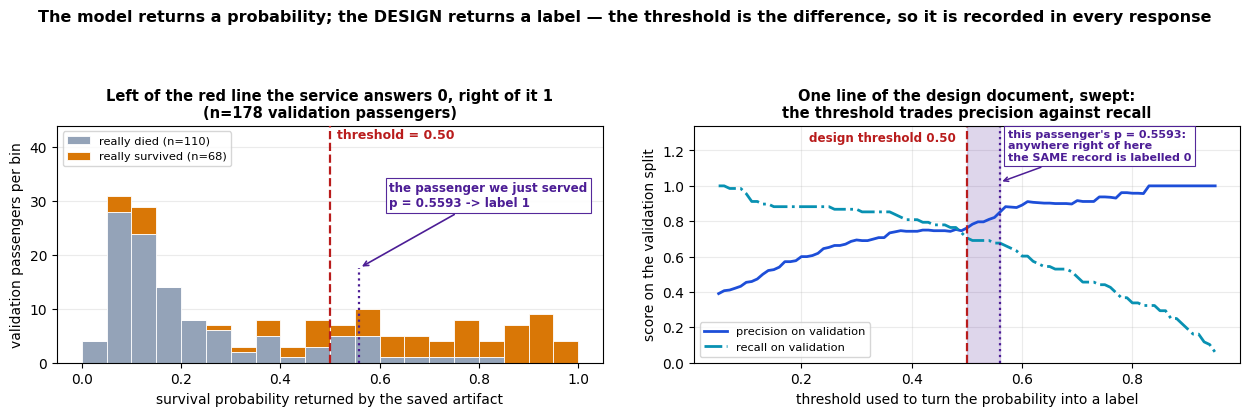

THRESHOLD IS A DESIGN DECISION — same model, same 178 validation rows, six thresholds
 threshold  labelled survivor  precision   recall      F1   this passenger (p=0.5593)
      0.30                 85     0.6941   0.8676  0.7712   -> label 1
      0.40                 74     0.7432   0.8088  0.7746   -> label 1
      0.50                 63     0.7619   0.7059  0.7328   -> label 1
      0.55                 56     0.8214   0.6765  0.7419   -> label 1
      0.60                 46     0.8913   0.6029  0.7193   -> label 0
      0.70                 36     0.9167   0.4853  0.6346   -> label 0

At 0.50 the service answers 1 for this passenger; at 0.60 the same artifact answers 0.
Nothing about the model changed. That is why `threshold_used` is in the output schema:
without it, a past decision cannot be reproduced, only guessed at.


In [14]:
# Part 6's picture: WHY the output schema carries `threshold_used`. The artifact returns a
# PROBABILITY; the label in the JSON response is that probability compared against a number the
# DESIGNER picked. Score the whole validation split with the artifact that was just loaded from
# disk, so the effect of that number is measured on real records instead of asserted in prose.
val_probability = served_model.predict_proba(X_val)[:, 1]      # exactly what the service computes
grid_thresholds = np.linspace(0.05, 0.95, 91)
precisions = [precision_score(y_val, val_probability >= t, zero_division=0) for t in grid_thresholds]
recalls = [recall_score(y_val, val_probability >= t, zero_division=0) for t in grid_thresholds]

fig, (ax_hist, ax_sweep) = plt.subplots(1, 2, figsize=(12.6, 4.2))

# LEFT — where the 178 validation passengers actually land on the probability axis, coloured by
# what really happened to them. The threshold is the vertical cut through this picture.
bins = np.linspace(0, 1, 21)
counts, _, _ = ax_hist.hist(
    [val_probability[y_val.to_numpy() == 0], val_probability[y_val.to_numpy() == 1]],
    bins=bins, stacked=True, color=["#94a3b8", "#d97706"], edgecolor="white", lw=0.6,
    label=["really died (n=%d)" % int((y_val == 0).sum()),
           "really survived (n=%d)" % int((y_val == 1).sum())])
top = float(np.max(counts)) * 1.42
ax_hist.set_ylim(0, top)
ax_hist.axvline(THRESHOLD, color="#b91c1c", ls="--", lw=1.6, zorder=5)
ax_hist.text(THRESHOLD + 0.015, top * 0.99, f"threshold = {THRESHOLD:.2f}", color="#b91c1c",
             fontsize=9, fontweight="bold", ha="left", va="top")
# Mark the served passenger with the same purple dotted idiom the right-hand panel uses
ax_hist.plot([probability, probability], [0, top * 0.40], color="#4c1d95", ls=":", lw=1.6, zorder=6)
ax_hist.annotate(f"the passenger we just served\np = {probability:.4f} -> label {response['predicted_label']}",
                 xy=(probability, top * 0.40), xytext=(probability + 0.06, top * 0.66),
                 fontsize=8.6, color="#4c1d95", fontweight="bold",
                 bbox=dict(fc="white", ec="#4c1d95", lw=0.8, alpha=0.95, pad=2.5),
                 arrowprops=dict(arrowstyle="->", color="#4c1d95", lw=1.2))
ax_hist.set_xlabel("survival probability returned by the saved artifact")
ax_hist.set_ylabel("validation passengers per bin")
ax_hist.set_title(f"Left of the red line the service answers 0, right of it 1\n(n={len(y_val)} validation passengers)",
                  fontsize=10.5, fontweight="bold")
ax_hist.legend(fontsize=8.2, loc="upper left")
ax_hist.grid(axis="y", alpha=0.25)
ax_hist.set_axisbelow(True)

# RIGHT — the same artifact, every threshold. Moving the number moves precision against recall.
ax_sweep.plot(grid_thresholds, precisions, lw=2.0, color="#1d4ed8", label="precision on validation")
ax_sweep.plot(grid_thresholds, recalls, lw=2.0, color="#0891b2", ls="-.", label="recall on validation")
ax_sweep.axvspan(THRESHOLD, probability, color="#4c1d95", alpha=0.18, zorder=1)
ax_sweep.axvline(THRESHOLD, color="#b91c1c", ls="--", lw=1.6)
ax_sweep.axvline(probability, color="#4c1d95", ls=":", lw=1.6)
# Headroom above the curves for the two callouts, so neither box ever covers a line
ax_sweep.set_ylim(0, 1.34)
ax_sweep.text(THRESHOLD - 0.02, 1.31, f"design threshold {THRESHOLD:.2f}", color="#b91c1c",
              fontsize=8.6, fontweight="bold", ha="right", va="top")
ax_sweep.annotate(f"this passenger's p = {probability:.4f}:\nanywhere right of here\nthe SAME record is labelled 0",
                  xy=(probability, 1.02), xytext=(probability + 0.015, 1.32),
                  color="#4c1d95", fontsize=8.0, fontweight="bold", ha="left", va="top",
                  bbox=dict(fc="white", ec="#4c1d95", lw=0.8, alpha=0.95, pad=2.5),
                  arrowprops=dict(arrowstyle="->", color="#4c1d95", lw=1.1), zorder=7)
ax_sweep.set_xlabel("threshold used to turn the probability into a label")
ax_sweep.set_ylabel("score on the validation split")
ax_sweep.set_title("One line of the design document, swept:\nthe threshold trades precision against recall",
                   fontsize=10.5, fontweight="bold")
ax_sweep.legend(fontsize=8.2, loc="lower left")
ax_sweep.grid(alpha=0.25)
ax_sweep.set_axisbelow(True)

fig.suptitle("The model returns a probability; the DESIGN returns a label — the threshold is the "
             "difference, so it is recorded in every response",
             fontsize=11.5, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

# The step table behind the right-hand panel: the same artifact, six thresholds, six systems.
print("=" * 96)
print("THRESHOLD IS A DESIGN DECISION — same model, same 178 validation rows, six thresholds")
print("=" * 96)
print(f"{'threshold':>10} {'labelled survivor':>18} {'precision':>10} {'recall':>8} {'F1':>7}   "
      f"this passenger (p={probability:.4f})")
for t in [0.30, 0.40, 0.50, 0.55, 0.60, 0.70]:
    predicted = (val_probability >= t).astype(int)
    print(f"{t:>10.2f} {int(predicted.sum()):>18} "
          f"{precision_score(y_val, predicted, zero_division=0):>10.4f} "
          f"{recall_score(y_val, predicted, zero_division=0):>8.4f} "
          f"{f1_score(y_val, predicted, zero_division=0):>7.4f}   "
          f"-> label {int(probability >= t)}")
print(f"\nAt {THRESHOLD:.2f} the service answers {response['predicted_label']} for this passenger; "
      f"at 0.60 the same artifact answers {int(probability >= 0.60)}.")
print("Nothing about the model changed. That is why `threshold_used` is in the output schema:")
print("without it, a past decision cannot be reproduced, only guessed at.")


**Reading the figure.** *Left:* the 178 validation passengers, placed on the probability axis by
the artifact that was just loaded from disk, and stacked by what actually happened to them. At the
two ends one colour dominates the bar; **in the middle bins grey and orange sit in the same bar** — that
mixed band is the population the threshold decides, and it is where every error the service will
make lives. The red line at **0.50** is not a property of the model; it is the line the *design*
drew. The purple marker is the passenger scored above, at **p = 0.5593** — inside the mixed band,
six hundredths from the line.

*Right:* the same artifact swept across every threshold. **Precision (solid blue) rises and recall
(dash-dot teal) falls** as the line moves right — that trade is what the number buys you. The
shaded purple band between the design threshold **0.50** and this passenger's **0.5593** is all the
headroom her answer has: push the threshold past 0.5593 and the identical record, from the
identical model, comes back labelled a non-survivor. The step table under the figure prices the
move: at 0.50 the service calls 63 of 178 survivors at precision 0.7619; at 0.60 it calls 46 at
precision 0.8913 and loses recall from 0.7059 to 0.6029.

That is the whole argument for `threshold_used` in the output schema. A logged probability with no
logged threshold cannot be re-decided later — and "why did the system say no in March?" is a
question you will be asked.

---

## Part 7 — Scalability, modularity and integration

### Scalability is a measurement, not an adjective

"The system will scale" is worth nothing at a design review. What is worth something: *"fitting
the pipeline takes T seconds at 100,000 rows; the production file has 284,807 rows; here is the
projection and here is how far off it was."*

You can do this today, before the system exists, with the pipeline you already have. Below, the
real credit-card transaction file is read at four real row counts, the pipeline is fitted at
each, and the trend is extrapolated to the full file — then the full file is actually fitted, so
the projection can be **checked instead of trusted**.

In [15]:
# Measure how the pipeline scales on REAL rows, then check the projection against reality.
# WHY read with usecols and nrows: a scalability experiment that runs out of memory teaches you
# nothing, and reading only the columns you need is itself the first scalability technique
# (AIAT 115 U5). Timings depend on your machine — read the shape of the trend, not the absolute
# numbers.
FRAUD_COLUMNS = ["V1", "V2", "V3", "V4", "V10", "V14", "Amount", "Class"]
SAMPLE_SIZES = [20_000, 50_000, 100_000, 200_000]

measurements = []
for n_rows in SAMPLE_SIZES:
    t0 = time.perf_counter()
    chunk = pd.read_csv(FRAUD, usecols=FRAUD_COLUMNS, nrows=n_rows)
    read_seconds = time.perf_counter() - t0

    features, labels = chunk.drop(columns=["Class"]), chunk["Class"]
    scaling_pipeline = Pipeline([("scale", StandardScaler()),
                                 ("model", LogisticRegression(max_iter=200,
                                                              random_state=RANDOM_STATE))])
    t0 = time.perf_counter()
    scaling_pipeline.fit(features, labels)
    fit_seconds = time.perf_counter() - t0

    measurements.append({"rows": n_rows,
                         "read_s": round(read_seconds, 3),
                         "fit_s": round(fit_seconds, 3),
                         "total_s": round(read_seconds + fit_seconds, 3)})

scaling = pd.DataFrame(measurements)
print("=" * 96)
print(f"SCALING MEASUREMENT — {FRAUD.name}, {len(FRAUD_COLUMNS)} columns")
print("=" * 96)
print(scaling.to_string(index=False))

# Linear projection from the measured points to the full file
full_rows = sum(1 for _ in open(FRAUD)) - 1        # count real rows without loading the file
slope, intercept = np.polyfit(scaling["rows"], scaling["total_s"], 1)
projected = slope * full_rows + intercept

t0 = time.perf_counter()
full = pd.read_csv(FRAUD, usecols=FRAUD_COLUMNS)
Pipeline([("scale", StandardScaler()),
          ("model", LogisticRegression(max_iter=200, random_state=RANDOM_STATE))]).fit(
    full.drop(columns=["Class"]), full["Class"])
actual = time.perf_counter() - t0

error_pct = abs(projected - actual) / actual * 100
print(f"\nFull file            : {full_rows:,} rows")
print(f"Projected read+fit   : {projected:.2f} s  (linear fit on the four measured points)")
print(f"Actually measured    : {actual:.2f} s")
print(f"Projection error     : {error_pct:.1f}%")
print("\nThis is the sentence your design document needs: a number, a projection, and the")
print("size of the gap between them. Your own timings will differ by machine — rerun and use yours.")

SCALING MEASUREMENT — creditcard_fraud.csv, 8 columns
  rows  read_s  fit_s  total_s
 20000   0.030  0.005    0.035
 50000   0.065  0.011    0.077
100000   0.121  0.020    0.141
200000   0.239  0.047    0.285



Full file            : 284,807 rows
Projected read+fit   : 0.40 s  (linear fit on the four measured points)
Actually measured    : 0.39 s
Projection error     : 1.6%

This is the sentence your design document needs: a number, a projection, and the
size of the gap between them. Your own timings will differ by machine — rerun and use yours.


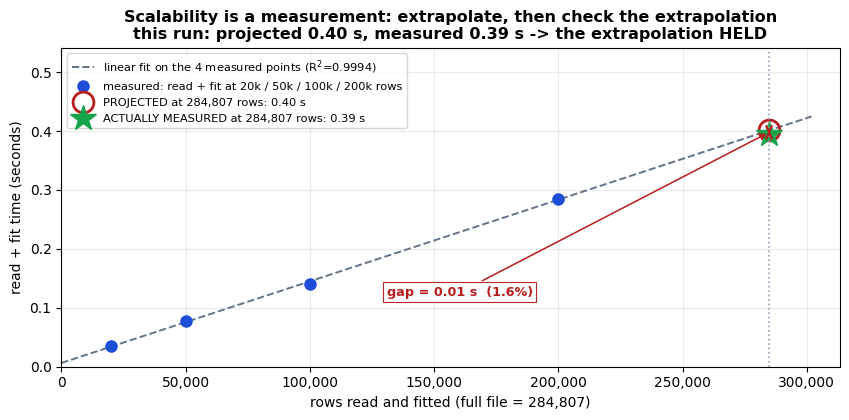

Measured points fall on a line with R^2 = 0.9994.
Projection 0.40 s vs measurement 0.39 s -> off by 1.6%.
Report BOTH numbers in your design document. A projection with no check is a guess with a decimal point.


In [16]:
# Plot the projection against the thing it projected. WHY: "it will scale" is an adjective, a
# table of four timings is data, but a line extrapolated to the full file WITH the real measurement
# on top of it is the only version that shows whether the projection can be trusted.
r_squared = np.corrcoef(scaling["rows"], scaling["total_s"])[0, 1] ** 2

fig, ax = plt.subplots(figsize=(8.6, 4.3))
grid = np.linspace(0, full_rows * 1.06, 60)
ax.plot(grid, slope * grid + intercept, ls="--", lw=1.4, color="#64748b",
        label=f"linear fit on the 4 measured points (R$^2$={r_squared:.4f})")
ax.plot(scaling["rows"], scaling["total_s"], "o", ms=8, color="#1d4ed8",
        label="measured: read + fit at 20k / 50k / 100k / 200k rows")
ax.plot([full_rows], [projected], "o", ms=15, mfc="none", mec="#b91c1c", mew=2.0,
        label=f"PROJECTED at {full_rows:,} rows: {projected:.2f} s")
ax.plot([full_rows], [actual], "*", ms=19, color="#16a34a",
        label=f"ACTUALLY MEASURED at {full_rows:,} rows: {actual:.2f} s")
ax.axvline(full_rows, color="#94a3b8", ls=":", lw=1.2)
# Draw the gap as an actual measured distance, so "how far off was the projection" is a length
# on the page and not only a number in a box.
ax.annotate("", xy=(full_rows, projected), xytext=(full_rows, actual),
            arrowprops=dict(arrowstyle="<->", color="#b91c1c", lw=1.6, shrinkA=0, shrinkB=0))
ax.annotate(f"gap = {abs(projected - actual):.2f} s  ({error_pct:.1f}%)",
            xy=(full_rows, (projected + actual) / 2),
            xytext=(full_rows * 0.46, max(projected, actual) * 0.30),
            fontsize=9.2, color="#b91c1c", fontweight="bold",
            bbox=dict(fc="white", ec="#b91c1c", lw=0.8, alpha=0.95, pad=2.5),
            arrowprops=dict(arrowstyle="->", color="#b91c1c", lw=1.1))
ax.xaxis.set_major_formatter(lambda value, _: f"{int(value):,}")

ax.set_xlabel(f"rows read and fitted (full file = {full_rows:,})")
ax.set_ylabel("read + fit time (seconds)")
# The verdict is written by the run, not by us: on a busy machine the projection can miss badly,
# and the figure has to say so instead of the caption assuming it did not.
verdict = ("the extrapolation HELD" if error_pct <= 10
           else f"the extrapolation was OPTIMISTIC by {error_pct:.0f}%")
ax.set_title("Scalability is a measurement: extrapolate, then check the extrapolation\n"
             f"this run: projected {projected:.2f} s, measured {actual:.2f} s -> {verdict}",
             fontsize=11.5, fontweight="bold")
ax.legend(fontsize=8.2, loc="upper left", frameon=True)
ax.grid(alpha=0.25)
ax.set_axisbelow(True)
ax.set_xlim(0, full_rows * 1.10)
ax.set_ylim(0, max(projected, actual, scaling["total_s"].max()) * 1.35)
plt.tight_layout()
plt.show()

print(f"Measured points fall on a line with R^2 = {r_squared:.4f}.")
print(f"Projection {projected:.2f} s vs measurement {actual:.2f} s -> off by {error_pct:.1f}%.")
print("Report BOTH numbers in your design document. A projection with no check is a guess with a"
      " decimal point.")


**Reading the figure.** The four blue points are real measurements at 20k / 50k / 100k / 200k
rows; the grey dashed line is the straight-line fit through them, extended to the full
284,807-row file. The two markers on the right-hand dotted line are the payoff: the **hollow red
circle is what the line predicted**, the **green star is what actually happened** when the whole
file was read and fitted, and the **red double-headed arrow between them measures the gap** —
printed in seconds and per cent, with the verdict on the figure's second title line. When the
projection is good the two markers nearly coincide and that arrow shrinks to almost nothing, which
is itself the result.

Read your own render, not this sentence. If the star lands on the dashed line, the projection held
and you may quote it in the design document. If it lands well above the line — which happens on a
busy laptop, or when fitting needs more iterations at full size — the extrapolation was optimistic,
and the honest design document carries the **measured** number with the projection error beside it.
Either way you leave with something no adjective gives you: a projection, a check, and the size of
the gap between them. Re-run it on your own project and your own machine; if your four points
already curve upward, say so before someone else notices.

### Modularity and integration — and where the CLO2 credit actually comes from

**Modularity** means one component can be replaced without the others noticing. The test is
mechanical: *if I swap this component for a different implementation, how many other components
change?* If the answer is more than zero, the interface is leaking.

**Integration** is the official point of AIAT 126. The course requires the project to draw on
several AI domains — machine learning, deep learning, natural language processing, computer
vision, data science — and **CLO2**, as written in the diploma's course-outcome list
(`docs/COMPLETE_COURSE_STRUCTURE_AND_CLOS.md`), is "Integrate knowledge from different AI
subdisciplines into a coherent and practical system".

The concrete way to satisfy that: **every component names the earlier course whose material it
reuses**, and that mapping goes into the **Prior Work Inventory** in your proposal
(`TEMPLATES/project_proposal_template.md`, section 6) and into the design document below. A
capstone that reuses nothing from AIAT 111–125 has not integrated anything; it has started over.

In [17]:
# Map every component to the earlier-course artifact it reuses. WHY this table is not decoration:
# it is the CLO2 evidence for gate 1 and gate 2, and it is also a plan — a component with a named
# prior artifact starts from working code instead of a blank file.
PRIOR_WORK = {
    "source": ("AIAT 115 U2", "Course 05/unit2-cleaning/examples/01_data_loading.ipynb",
               "REUSE — same loading/inspection routine, new file"),
    "prep": ("AIAT 114 U1 + AIAT 115 U2",
             "Course 04/unit1-regression-algorithms/examples/03_data_preprocessing.ipynb",
             "EXTEND — same ColumnTransformer pattern, new column list from the Part 4 plan"),
    "train": ("AIAT 114 U3 + U5",
              "Course 04/unit3-classification/examples/01_logistic_regression.ipynb",
              "REUSE — classifier and metrics; grid search from unit5/01_grid_search.ipynb"),
    "store": ("AIAT 125 U2",
              "Course 11/unit2-versioning-serving/examples/04_saving_loading_models_pickle_onnx.ipynb",
              "REUSE — joblib artifact + version naming convention"),
    "serve": ("AIAT 125 U2",
              "Course 11/unit2-versioning-serving/examples/02_fastapi_deployment.ipynb",
              "EXTEND — same endpoint shape, new request schema from Part 6"),
    "monitor": ("AIAT 125 U5",
                "Course 11/unit5-pipelines-monitoring/examples/04_drift_detection.ipynb",
                "EXTEND — drift check plus the per-subgroup metric this project needs"),
    "risk review": ("AIAT 116 U2 + U4",
                    "Course 06/unit2-bias-fairness/examples/01_bias_detection.ipynb",
                    "REUSE — bias detection applied to the Sex disparity found in Part 5"),
}

inventory = pd.DataFrame(
    [{"component": k, "prior course": v[0], "artifact": v[1], "reuse or extend": v[2]}
     for k, v in PRIOR_WORK.items()])
print("=" * 110)
print("PRIOR WORK INVENTORY — the CLO2 evidence (goes in the proposal, section 6)")
print("=" * 110)
print(inventory.to_string(index=False))

courses_used = sorted({v[0].split(" U")[0].split(" +")[0] for v in PRIOR_WORK.values()})
print(f"\nDistinct earlier courses reused: {len(courses_used)} -> {', '.join(courses_used)}")
print("Gate 1 asks for at least three components mapped to at least three different courses.")

# Modularity self-test: which components would change if the model were swapped for a neural net?
print("\nModularity self-test — 'swap the model for a small neural network (AIAT 122). "
      "What else changes?'")
for component in ["source", "prep", "store", "serve", "monitor"]:
    unaffected = component in {"source", "prep", "serve", "monitor"}
    print(f"  {component:<9} {'unchanged — the interface holds' if unaffected else 'CHANGES — a Keras model is not a .joblib pipeline'}")
print("\nOne component changes. That is what modular means, and it is why the artifact store")
print("is the component whose format you should agree on first.")

PRIOR WORK INVENTORY — the CLO2 evidence (goes in the proposal, section 6)
  component              prior course                                                                               artifact                                                               reuse or extend
     source               AIAT 115 U2                                Course 05/unit2-cleaning/examples/01_data_loading.ipynb                             REUSE — same loading/inspection routine, new file
       prep AIAT 114 U1 + AIAT 115 U2             Course 04/unit1-regression-algorithms/examples/03_data_preprocessing.ipynb EXTEND — same ColumnTransformer pattern, new column list from the Part 4 plan
      train          AIAT 114 U3 + U5                   Course 04/unit3-classification/examples/01_logistic_regression.ipynb   REUSE — classifier and metrics; grid search from unit5/01_grid_search.ipynb
      store               AIAT 125 U2 Course 11/unit2-versioning-serving/examples/04_saving_loading_models_pickle

---

## Part 8 — The design document deliverable

Everything above becomes **one document**, which is the graded artifact for this unit (gate 2,
10 points, and implementation may not begin until it passes).

The twelve sections below are the **six keys** from the Unit 2 exercise primer
(`project_name`, `components`, `data_flow`, `model_selection`, `data_formats_storage`,
`risks_dependencies`) **plus the six** the official unit content adds: the prior work inventory,
dataset selection, platform selection, the data plan, the evaluation plan, and the scalability
plan.

The validator is not a formality. It refuses to emit a document that:

- is missing a required section, or has an empty one,
- still contains the string `TODO` anywhere,
- names a model with no justification, or with no rejected alternative,
- states no baseline in the evaluation plan,
- maps fewer than **three** components to earlier AIAT 111–125 artifacts (the CLO2 floor).

In [18]:
# The design-document specification: an ordered list of (key, heading, how to render it).
# WHY specify the document as data: the validator, the renderer and the student scaffold all read
# this one list, so a section can never be checked but not printed, or printed but not checked.
DESIGN_SECTIONS = [
    ("project_name",          "Project",                              "text"),
    ("prior_work_inventory",  "Prior Work Inventory (AIAT 111-125)",  "mapping"),
    ("components",            "System components",                    "list"),
    ("data_flow",             "Data flow",                            "text"),
    ("dataset_selection",     "Dataset selection and justification",  "mapping"),
    ("model_selection",       "Model and algorithm selection",        "mapping"),
    ("platform_selection",    "Platform and tooling selection",       "mapping"),
    ("data_plan",             "Data collection and preprocessing plan", "list"),
    ("evaluation_plan",       "Evaluation metrics and baselines",     "mapping"),
    ("data_formats_storage",  "Input/output formats and storage",     "text"),
    ("scalability_plan",      "Scalability, modularity and integration", "list"),
    ("risks_dependencies",    "Risks and dependencies",               "list"),
]
REQUIRED_KEYS = [key for key, _, _ in DESIGN_SECTIONS]


def _walk_strings(value):
    """Yield every string anywhere in a nested dict/list — used for the TODO sweep."""
    if isinstance(value, str):
        yield value
    elif isinstance(value, dict):
        for item in value.values():
            yield from _walk_strings(item)
    elif isinstance(value, (list, tuple)):
        for item in value:
            yield from _walk_strings(item)


def check_design(design):
    """Return the list of problems that block this document from being submitted."""
    problems = []

    for key in REQUIRED_KEYS:
        if key not in design:
            problems.append(f"missing section: '{key}'")
        elif not design[key]:
            problems.append(f"empty section: '{key}'")

    todos = sorted({s for s in _walk_strings(design) if "TODO" in s})
    for todo in todos:
        problems.append(f"unfinished placeholder: {todo[:70]!r}")

    model = design.get("model_selection") or {}
    if not model.get("justification"):
        problems.append("model_selection has no justification (naming a model is not choosing one)")
    if not model.get("alternatives_considered"):
        problems.append("model_selection lists no rejected alternative with a reason")

    evaluation = design.get("evaluation_plan") or {}
    if not evaluation.get("baselines"):
        problems.append("evaluation_plan states no baseline to beat")
    if not evaluation.get("primary_metric"):
        problems.append("evaluation_plan names no primary metric")

    inventory = design.get("prior_work_inventory") or {}
    mapped = [k for k, v in inventory.items() if v and "TODO" not in str(v)]
    if len(mapped) < 3:
        problems.append(
            f"prior_work_inventory maps only {len(mapped)} component(s) to AIAT 111-125 artifacts; "
            "gate 1 requires at least 3 (CLO2)")

    return problems


def render_design_document(design):
    """Render the design dictionary as the markdown document a reviewer reads."""
    lines = [f"# Design Document — {design.get('project_name', '(unnamed project)')}", "",
             "*Generated from the design dictionary by the AIAT 126 Unit 2 notebook.*", ""]
    for index, (key, heading, kind) in enumerate(DESIGN_SECTIONS, start=1):
        if key == "project_name":
            continue
        value = design.get(key, "")
        lines += [f"## {index - 1}. {heading}", ""]
        if kind == "list":
            lines += [f"- {item}" for item in value] or ["- (empty)"]
        elif kind == "mapping":
            for sub_key, sub_value in (value or {}).items():
                pretty = sub_key.replace("_", " ")
                if isinstance(sub_value, (list, tuple)):
                    lines.append(f"- **{pretty}:**")
                    lines += [f"  - {item}" for item in sub_value]
                else:
                    lines.append(f"- **{pretty}:** {sub_value}")
        else:
            lines.append(str(value) or "(empty)")
        lines.append("")
    return "\n".join(lines)


print(f"Design document specification loaded: {len(DESIGN_SECTIONS)} required sections.")
print("check_design() enforces them; render_design_document() prints them.")

Design document specification loaded: 12 required sections.
check_design() enforces them; render_design_document() prints them.


In [19]:
# The worked example, written out in full and validated. WHY every number below is one this
# notebook actually computed: a design document quoting numbers nobody measured is the exact
# habit gate 4 is designed to catch, and it starts here.
example_design = {
    "project_name": "Titanic survival-risk scoring service (worked example)",

    "prior_work_inventory": {
        component: f"{course} — {artifact} — {mode}"
        for component, (course, artifact, mode) in PRIOR_WORK.items()
    },

    "components": [f"{c['id']} — {c['does']} | reads: {c['reads']} | writes: {c['writes']}"
                   for c in COMPONENTS],

    "data_flow": " ; ".join(f"{a} -> {b} ({label})" for a, b, label in FLOWS),

    "dataset_selection": {
        "chosen": f"{TITANIC.name} — {len(raw)} rows x {raw.shape[1]} columns, 1912 passenger manifest",
        "why": ("real missingness (Age 19.9%, Cabin 77.1%), a real 61.8/38.2 class split and a "
                "real subgroup disparity, so every pipeline step is exercised by the data itself"),
        "licence": "public-domain historical record; coursework use permitted",
        "excluded": ("Cabin (77.1% missing), Name (free text, 891/891 distinct), "
                     "Ticket (681 categories for 891 rows), PassengerId (identifier)"),
        "fallback_if_unavailable": "any tabular binary-outcome dataset with >10% missingness",
    },

    "model_selection": {
        "chosen_model": f"{chosen_name} on imputed + one-hot-encoded + scaled features",
        "justification": (
            f"{len(X_train)} training rows and {len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)} "
            f"features: a linear model is fast, needs no tuning budget, and gives a coefficient per "
            f"feature that can be shown to an affected person. Measured on validation: accuracy "
            f"{evidence[chosen_name]['accuracy']}, F1 {evidence[chosen_name]['f1']}"),
        "alternatives_considered": [
            (f"Decision tree (depth 4) — higher accuracy "
             f"({evidence['Decision tree (depth 4)']['accuracy']}) but lower F1 "
             f"({evidence['Decision tree (depth 4)']['f1']}); kept as the fallback candidate"),
            "Random forest — rejected: loses the per-feature explanation this use case needs",
            f"Fine-tuned transformer — rejected: no text input, and {len(raw)} rows cannot support it",
        ],
        "decision_matrix_winner": winner,
    },

    "platform_selection": {
        "training_environment": "local CPU, the shared course venv (ai-diploma kernel)",
        "why_training": f"the full fit takes under a second on {len(X_train)} rows; a GPU would idle",
        "serving_target": "single-process FastAPI container (pattern from AIAT 125 U2)",
        "why_serving": (f"the artifact is {model_path.stat().st_size:,} bytes and loads at startup, "
                        "so one small container serves the expected request rate"),
        "rejected": "managed cloud endpoint — cost and account setup exceed the course scope",
    },

    "data_plan": [f"{row['column']}: {row['planned action']} ({row['reason (from the profile)']})"
                  for _, row in data_plan.iterrows()],

    "evaluation_plan": {
        "primary_metric": "F1 on the positive (survived) class",
        "why_this_metric": (f"the majority-class baseline reaches accuracy "
                            f"{comparison.loc[f'BASELINE 0 — always predict {majority_class}', 'accuracy']} "
                            f"with F1 0.0 — accuracy cannot distinguish a useful model from a "
                            f"constant one on this split"),
        "baselines": [
            (f"majority class: accuracy "
             f"{comparison.loc[f'BASELINE 0 — always predict {majority_class}', 'accuracy']}, F1 "
             f"{comparison.loc[f'BASELINE 0 — always predict {majority_class}', 'f1']}"),
            f"domain rule (female -> survived): accuracy {must_beat_acc}, F1 {must_beat_f1}",
        ],
        "must_beat": f"F1 > {must_beat_f1} on validation, before the test set is opened once at gate 4",
        "protocol": "60/20/20 stratified split, random_state=42; test measured exactly once",
    },

    "data_formats_storage": (
        f"Input: JSON record validated against {len(INPUT_SCHEMA)} fields "
        f"({', '.join(INPUT_SCHEMA)}). Output: JSON with {', '.join(OUTPUT_SCHEMA)}. "
        f"Artifacts in {ARTIFACT_DIR}/ as {MODEL_VERSION}.joblib "
        f"({model_path.stat().st_size:,} bytes) plus .schema.json and .metrics.json."),

    "scalability_plan": [
        (f"measured on {full_rows:,} real rows of {FRAUD.name}: linear projection from four "
         f"sample sizes missed the measured full-data time by {error_pct:.1f}%"),
        "read only the required columns (usecols) — the first scalability technique, from AIAT 115 U5",
        "modularity: swapping the estimator changes the artifact-store format only; "
        "source, preprocessing, serving and monitoring interfaces hold",
        "integration: every component maps to a named AIAT 111-125 artifact (see section 1)",
    ],

    "risks_dependencies": [
        ("LEGAL/ETHICAL — the strongest single predictor is Sex "
         f"(survival {by_sex.loc['female', 'mean']} female vs {by_sex.loc['male', 'mean']} male). "
         "Scoring living people on a protected attribute is a fairness and legal problem: run the "
         "AIAT 116 U2 bias check and report per-subgroup metrics, or restrict the system to "
         "historical analysis."),
        (f"DATA — Cabin is {profile.loc['Cabin', 'missing_%']}% missing and is dropped; if a later "
         "requirement needs deck information the dataset cannot supply it."),
        ("DATA — the domain-rule baseline ties or beats two of the candidate models, so the "
         "project must either add features with independent signal or narrow its claim."),
        ("TECHNICAL — scikit-learn and joblib versions pinned in requirements.txt; a .joblib "
         "artifact does not load across major versions."),
    ],
}

problems = check_design(example_design)
print(f"check_design() on the worked example -> {len(problems)} problem(s): "
      f"{problems if problems else 'none, the document may be submitted'}")

document = render_design_document(example_design)
OUTPUT_PATH = Path("design_document_example.md")
OUTPUT_PATH.write_text(document, encoding="utf-8")
print(f"Written: {OUTPUT_PATH}  ({len(document):,} characters)")
print(f"{len(DESIGN_SECTIONS)} specified sections -> {len(DESIGN_SECTIONS) - 1} numbered "
      f"headings in the document (project_name becomes the title, not a numbered section).")

check_design() on the worked example -> 0 problem(s): none, the document may be submitted
Written: design_document_example.md  (7,566 characters)
12 specified sections -> 11 numbered headings in the document (project_name becomes the title, not a numbered section).


In [20]:
# Display the generated document so you can see what the reviewer will see. WHY render it here:
# the deliverable is a document, not a dictionary, and the two are easy to confuse until you
# read the rendered version once.
display(Markdown(document))

# Design Document — Titanic survival-risk scoring service (worked example)

*Generated from the design dictionary by the AIAT 126 Unit 2 notebook.*

## 1. Prior Work Inventory (AIAT 111-125)

- **source:** AIAT 115 U2 — Course 05/unit2-cleaning/examples/01_data_loading.ipynb — REUSE — same loading/inspection routine, new file
- **prep:** AIAT 114 U1 + AIAT 115 U2 — Course 04/unit1-regression-algorithms/examples/03_data_preprocessing.ipynb — EXTEND — same ColumnTransformer pattern, new column list from the Part 4 plan
- **train:** AIAT 114 U3 + U5 — Course 04/unit3-classification/examples/01_logistic_regression.ipynb — REUSE — classifier and metrics; grid search from unit5/01_grid_search.ipynb
- **store:** AIAT 125 U2 — Course 11/unit2-versioning-serving/examples/04_saving_loading_models_pickle_onnx.ipynb — REUSE — joblib artifact + version naming convention
- **serve:** AIAT 125 U2 — Course 11/unit2-versioning-serving/examples/02_fastapi_deployment.ipynb — EXTEND — same endpoint shape, new request schema from Part 6
- **monitor:** AIAT 125 U5 — Course 11/unit5-pipelines-monitoring/examples/04_drift_detection.ipynb — EXTEND — drift check plus the per-subgroup metric this project needs
- **risk review:** AIAT 116 U2 + U4 — Course 06/unit2-bias-fairness/examples/01_bias_detection.ipynb — REUSE — bias detection applied to the Sex disparity found in Part 5

## 2. System components

- source — Titanic manifest CSV · 891 rows × 12 cols | reads: titanic.csv (read-only, licensed for coursework) | writes: raw DataFrame
- prep — impute · encode · scale (fit on TRAIN only) | reads: raw DataFrame | writes: feature matrix + a FITTED transformer object
- train — 2 candidates, chosen on validation | reads: feature matrix (train split) | writes: fitted estimator + validation metrics
- store — model.joblib · schema.json · metrics.json | reads: fitted estimator, fitted transformer, metrics | writes: versioned files on disk
- request — one passenger record as JSON | reads: caller input | writes: validated record matching schema.json
- serve — loads artifacts, applies the same preprocessing | reads: schema-valid record + artifacts | writes: probability + label
- response — JSON: probability · label · model version | reads: probability + label | writes: JSON to the caller
- monitor — logs I/O · drift · per-subgroup metrics | reads: every request and response | writes: append-only log + alerts

## 3. Data flow

source -> prep (raw rows) ; prep -> train (train matrix) ; train -> store (fitted artifacts) ; store -> serve (loaded at startup) ; request -> serve (JSON in) ; serve -> response (JSON out) ; serve -> monitor (every prediction logged)

## 4. Dataset selection and justification

- **chosen:** titanic.csv — 891 rows x 12 columns, 1912 passenger manifest
- **why:** real missingness (Age 19.9%, Cabin 77.1%), a real 61.8/38.2 class split and a real subgroup disparity, so every pipeline step is exercised by the data itself
- **licence:** public-domain historical record; coursework use permitted
- **excluded:** Cabin (77.1% missing), Name (free text, 891/891 distinct), Ticket (681 categories for 891 rows), PassengerId (identifier)
- **fallback if unavailable:** any tabular binary-outcome dataset with >10% missingness

## 5. Model and algorithm selection

- **chosen model:** Logistic regression on imputed + one-hot-encoded + scaled features
- **justification:** 534 training rows and 7 features: a linear model is fast, needs no tuning budget, and gives a coefficient per feature that can be shown to an affected person. Measured on validation: accuracy 0.8034, F1 0.7328
- **alternatives considered:**
  - Decision tree (depth 4) — higher accuracy (0.8146) but lower F1 (0.7273); kept as the fallback candidate
  - Random forest — rejected: loses the per-feature explanation this use case needs
  - Fine-tuned transformer — rejected: no text input, and 891 rows cannot support it
- **decision matrix winner:** Decision tree (depth 4)

## 6. Platform and tooling selection

- **training environment:** local CPU, the shared course venv (ai-diploma kernel)
- **why training:** the full fit takes under a second on 534 rows; a GPU would idle
- **serving target:** single-process FastAPI container (pattern from AIAT 125 U2)
- **why serving:** the artifact is 4,442 bytes and loads at startup, so one small container serves the expected request rate
- **rejected:** managed cloud endpoint — cost and account setup exceed the course scope

## 7. Data collection and preprocessing plan

- PassengerId: DROP (identifier) (unique per row — an ID carries no signal, only leakage risk)
- Survived: keep as target (never imputed; rows with a missing target are dropped)
- Pclass: standard-scale (numeric, 0 missing (0.0%))
- Name: OUT OF SCOPE (or separate text component) (891 distinct values in 891 rows — free text, not a category)
- Sex: one-hot encode (2 categories, 0 missing)
- Age: median impute + standard-scale (numeric, 177 missing (19.9%))
- SibSp: standard-scale (numeric, 0 missing (0.0%))
- Parch: standard-scale (numeric, 0 missing (0.0%))
- Ticket: GROUP or EXCLUDE (high cardinality) (681 categories for 891 rows — one-hot would add more columns than the data can support)
- Fare: standard-scale (numeric, 0 missing (0.0%))
- Cabin: DROP (77.1% missing — imputing this would be inventing data)
- Embarked: most-frequent impute + one-hot encode (3 categories, 2 missing)

## 8. Evaluation metrics and baselines

- **primary metric:** F1 on the positive (survived) class
- **why this metric:** the majority-class baseline reaches accuracy 0.618 with F1 0.0 — accuracy cannot distinguish a useful model from a constant one on this split
- **baselines:**
  - majority class: accuracy 0.618, F1 0.0
  - domain rule (female -> survived): accuracy 0.8034, F1 0.7368
- **must beat:** F1 > 0.7368 on validation, before the test set is opened once at gate 4
- **protocol:** 60/20/20 stratified split, random_state=42; test measured exactly once

## 9. Input/output formats and storage

Input: JSON record validated against 7 fields (Pclass, Sex, Age, SibSp, Parch, Fare, Embarked). Output: JSON with survival_probability, predicted_label, threshold_used, model_version. Artifacts in artifacts_example/ as titanic-survival-v0.1.joblib (4,442 bytes) plus .schema.json and .metrics.json.

## 10. Scalability, modularity and integration

- measured on 284,807 real rows of creditcard_fraud.csv: linear projection from four sample sizes missed the measured full-data time by 1.6%
- read only the required columns (usecols) — the first scalability technique, from AIAT 115 U5
- modularity: swapping the estimator changes the artifact-store format only; source, preprocessing, serving and monitoring interfaces hold
- integration: every component maps to a named AIAT 111-125 artifact (see section 1)

## 11. Risks and dependencies

- LEGAL/ETHICAL — the strongest single predictor is Sex (survival 0.742 female vs 0.1889 male). Scoring living people on a protected attribute is a fairness and legal problem: run the AIAT 116 U2 bias check and report per-subgroup metrics, or restrict the system to historical analysis.
- DATA — Cabin is 77.1% missing and is dropped; if a later requirement needs deck information the dataset cannot supply it.
- DATA — the domain-rule baseline ties or beats two of the candidate models, so the project must either add features with independent signal or narrow its claim.
- TECHNICAL — scikit-learn and joblib versions pinned in requirements.txt; a .joblib artifact does not load across major versions.


### Now yours

Replace every `TODO` below with your own project. The rules are the ones the validator enforces,
which are the ones the gate-2 rubric scores:

- every section filled, nothing left as `TODO`;
- a model **with** a justification citing *your* data type, size and constraints, and **with** a
  rejected alternative and the reason;
- an evaluation plan with a **primary metric** and at least one **baseline you can compute today**;
- a **Prior Work Inventory** mapping at least **three** components to named AIAT 111–125 artifacts.

Then pass your own `components` and `flows` to `draw_architecture(...)` — if it raises, your
diagram and your design disagree, and fixing that now costs minutes instead of a resubmission.

The cell deliberately **refuses to write the file** while problems remain. That is the design
review, run by you, before it is run by your instructor.

In [21]:
# YOUR design document. Fill this in for your own capstone project, then run the cell.
# The checker lists everything that would be deducted at gate 2; the file is only written once
# the list is empty. WHY it refuses: an unfinished design document that looks finished is worse
# than an obviously unfinished one.
my_design = {
    "project_name": "TODO: your project title",

    # CLO2 — name the earlier-course artifact each component reuses or extends.
    # At least three components must map to real AIAT 111-125 artifacts.
    "prior_work_inventory": {
        "dataset": "TODO: e.g. AIAT 115 U2 — Course 05/unit2-cleaning/examples/01_data_loading.ipynb — REUSE",
        "model": "TODO: which AIAT 114 / 121 / 122 / 124 notebook your model comes from",
        "pipeline": "TODO: which preprocessing/training pipeline you extend",
        "deployment_target": "TODO: which AIAT 125 serving pattern you reuse",
        "ethics_review": "TODO: which AIAT 116 notebook your bias/privacy check comes from",
    },

    "components": ["TODO: id — what it does | reads: ... | writes: ..."],
    "data_flow": "TODO: source -> preprocessing -> model -> output (adapt to your design)",

    "dataset_selection": {
        "chosen": "TODO: name, rows x columns, source",
        "why": "TODO: why this dataset can answer your problem",
        "licence": "TODO: what the licence permits for coursework",
        "fallback_if_unavailable": "TODO: the dataset you switch to if this one disappears",
    },

    "model_selection": {
        "chosen_model": "TODO",
        "justification": "TODO: cite YOUR data type, YOUR data size, YOUR constraints",
        "alternatives_considered": ["TODO: one alternative AND the reason you rejected it"],
    },

    "platform_selection": {
        "training_environment": "TODO: local CPU / GPU / Colab, and why",
        "serving_target": "TODO: script, API, container, or notebook, and why",
    },

    "data_plan": ["TODO: one line per column or per collection step, with the reason"],

    "evaluation_plan": {
        "primary_metric": "TODO: the one number the project is judged on",
        "why_this_metric": "TODO: tie it to the harm you are avoiding",
        "baselines": ["TODO: a baseline you can compute today, with its number"],
        "must_beat": "TODO: the threshold gate 4 will check you against",
    },

    "data_formats_storage": "TODO: input format, output format, where artifacts live",
    "scalability_plan": ["TODO: a measured number, not an adjective"],
    "risks_dependencies": ["TODO: at least one legal/ethical, one data, one technical"],
}

my_problems = check_design(my_design)
print("=" * 96)
print(f"DESIGN REVIEW SELF-CHECK — {len(my_problems)} problem(s) found")
print("=" * 96)
for problem in my_problems:
    print(f"  - {problem}")

if my_problems:
    print("\nDocument NOT written. Fix the list above and re-run this cell.")
    print("(This is the expected output until you replace the TODO scaffold with your project.)")
else:
    my_path = Path("design_document.md")
    my_path.write_text(render_design_document(my_design), encoding="utf-8")
    print(f"\nNo problems. Written: {my_path} — this is your gate-2 submission.")
    display(Markdown(render_design_document(my_design)))

DESIGN REVIEW SELF-CHECK — 26 problem(s) found
  - unfinished placeholder: 'TODO'
  - unfinished placeholder: 'TODO: a baseline you can compute today, with its number'
  - unfinished placeholder: 'TODO: a measured number, not an adjective'
  - unfinished placeholder: 'TODO: at least one legal/ethical, one data, one technical'
  - unfinished placeholder: 'TODO: cite YOUR data type, YOUR data size, YOUR constraints'
  - unfinished placeholder: 'TODO: e.g. AIAT 115 U2 — Course 05/unit2-cleaning/examples/01_data_loa'
  - unfinished placeholder: 'TODO: id — what it does | reads: ... | writes: ...'
  - unfinished placeholder: 'TODO: input format, output format, where artifacts live'
  - unfinished placeholder: 'TODO: local CPU / GPU / Colab, and why'
  - unfinished placeholder: 'TODO: name, rows x columns, source'
  - unfinished placeholder: 'TODO: one alternative AND the reason you rejected it'
  - unfinished placeholder: 'TODO: one line per column or per collection step, with the reason'
 

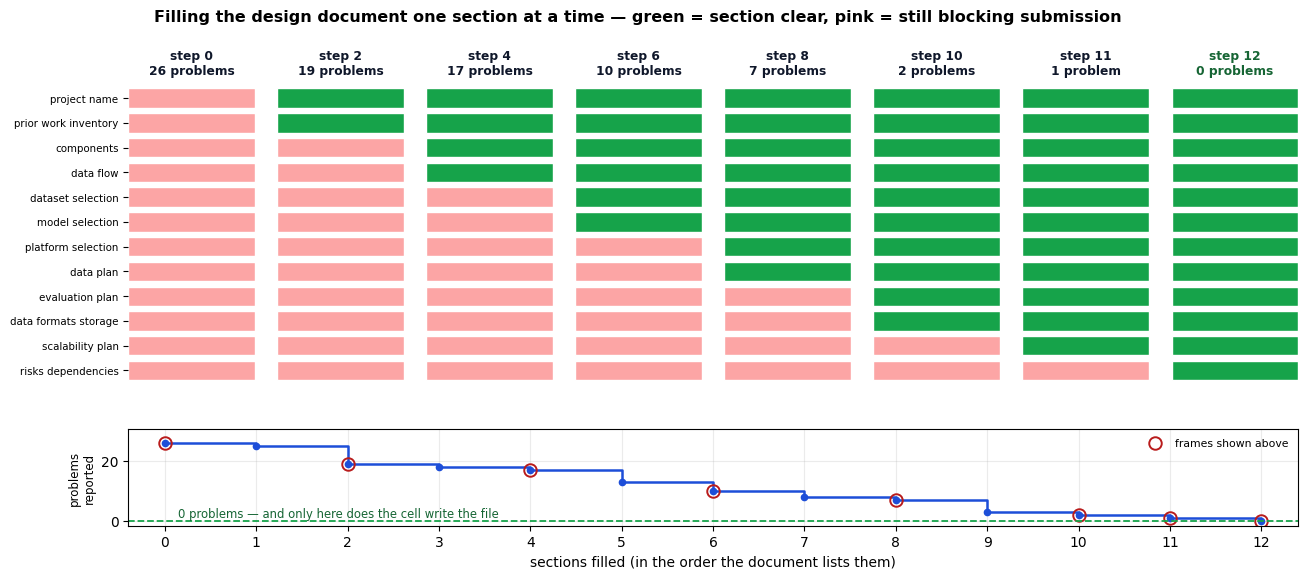

STEP TABLE — what the validator said after each section was filled
 step                    section filled  problems left writes file?
    0 (nothing yet — the TODO scaffold)             26           no
    1                      project_name             25           no
    2              prior_work_inventory             19           no
    3                        components             18           no
    4                         data_flow             17           no
    5                 dataset_selection             13           no
    6                   model_selection             10           no
    7                platform_selection              8           no
    8                         data_plan              7           no
    9                   evaluation_plan              3           no
   10              data_formats_storage              2           no
   11                  scalability_plan              1           no
   12                risks_dependencies          

In [22]:
# STEP STORYBOARD — a design document is not written in one pass. Replay the process: start from
# the TODO scaffold above, fill ONE section at a time with the worked example's content, and re-run
# the real check_design() after every step. WHY a storyboard and not prose: students see the "26
# problems" wall once and assume the validator is hostile. Watching the count fall shows it is a
# to-do list that finishes.
import copy

progress = copy.deepcopy(my_design)                     # step 0 = the TODO scaffold, unchanged
states = [copy.deepcopy(progress)]
history = [{"step": 0, "section filled": "(nothing yet — the TODO scaffold)",
            "problems left": len(check_design(progress)), "writes file?": "no"}]
for step_number, key in enumerate(REQUIRED_KEYS, start=1):
    progress[key] = copy.deepcopy(example_design[key])  # borrow the worked example, section by section
    remaining = len(check_design(progress))
    states.append(copy.deepcopy(progress))
    history.append({"step": step_number, "section filled": key, "problems left": remaining,
                    "writes file?": "YES" if remaining == 0 else "no"})


def section_is_clear(design, key):
    """One section's status: present, non-empty, and free of any TODO string."""
    value = design.get(key)
    return bool(value) and not any("TODO" in s for s in _walk_strings(value))


# Cap the storyboard at 8 frames so it stays readable on a projector
frame_steps = [0, 2, 4, 6, 8, 10, 11, 12]
fig = plt.figure(figsize=(13.6, 5.9))
grid = fig.add_gridspec(2, len(frame_steps), height_ratios=[3.6, 1.15], hspace=0.22, wspace=0.18,
                        left=0.125, right=0.985, top=0.855, bottom=0.105)

for position, step_number in enumerate(frame_steps):
    ax = fig.add_subplot(grid[0, position])
    state = states[step_number]
    clear = [section_is_clear(state, key) for key in REQUIRED_KEYS]
    ax.barh(range(len(REQUIRED_KEYS)), 1, height=0.78,
            color=["#16a34a" if ok else "#fca5a5" for ok in clear], edgecolor="white")
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.6, len(REQUIRED_KEYS) - 0.4)
    ax.invert_yaxis()
    ax.set_xticks([])
    if position == 0:
        ax.set_yticks(range(len(REQUIRED_KEYS)))
        ax.set_yticklabels([k.replace("_", " ") for k in REQUIRED_KEYS], fontsize=7.4)
    else:
        ax.set_yticks([])
    problems_left = history[step_number]["problems left"]
    ax.set_title(f"step {step_number}\n{problems_left} problem"
                 f"{'' if problems_left == 1 else 's'}", fontsize=8.8,
                 fontweight="bold", color="#166534" if problems_left == 0 else "#0f172a")
    for spine in ax.spines.values():
        spine.set_visible(False)

# Bottom lane: the validator's answer at every one of the 13 states
curve_ax = fig.add_subplot(grid[1, :])
steps = [h["step"] for h in history]
problems = [h["problems left"] for h in history]
curve_ax.step(steps, problems, where="post", color="#1d4ed8", lw=1.8)
curve_ax.plot(steps, problems, "o", ms=4.5, color="#1d4ed8")
curve_ax.plot(frame_steps, [problems[s] for s in frame_steps], "o", ms=9, mfc="none",
              mec="#b91c1c", mew=1.4, label="frames shown above")
curve_ax.axhline(0, color="#16a34a", ls="--", lw=1.3)
curve_ax.text(0.15, 1.4, "0 problems — and only here does the cell write the file",
              fontsize=8.4, color="#166534")
curve_ax.set_xticks(steps)
curve_ax.set_xlabel("sections filled (in the order the document lists them)")
curve_ax.set_ylabel("problems\nreported", fontsize=8.5)
curve_ax.set_xlim(-0.4, 12.4)
curve_ax.set_ylim(-1.5, max(problems) * 1.18)
curve_ax.legend(fontsize=7.8, loc="upper right", frameon=False)
curve_ax.grid(alpha=0.25)
curve_ax.set_axisbelow(True)

fig.suptitle("Filling the design document one section at a time — green = section clear, "
             "pink = still blocking submission", fontsize=11.5, fontweight="bold")
plt.show()

print("=" * 96)
print("STEP TABLE — what the validator said after each section was filled")
print("=" * 96)
print(pd.DataFrame(history).to_string(index=False))
print(f"\nStart: {problems[0]} problems. End: {problems[-1]}. "
      f"Largest single drop: {max(problems[i] - problems[i + 1] for i in range(len(problems) - 1))} "
      f"problems, at step {int(np.argmax(np.diff(problems) * -1)) + 1} "
      f"({history[int(np.argmax(np.diff(problems) * -1)) + 1]['section filled']}).")


**Reading the storyboard.** Read the frames left to right. Each column is the same twelve
sections; a section turns from pink to green the moment it holds real content with no `TODO` left
in it. Nothing else changes — the validator is not being appeased, it is being *answered*.

Two things to notice. First, the count in the bottom lane **falls all the way to the last step**:
the file is written at step 12 and at no step before it, even though the document looks nearly
finished at step 10. A design document that is 90% done is a design document that does not exist.
Second, the drops are **uneven** — the step table under the figure shows the Prior Work Inventory
clearing **six** problems in one move (25 → 19), because it holds five placeholders *and* trips the
separate CLO2 check for three named AIAT 111–125 artifacts. The evaluation plan clears four
(7 → 3) for the same reason: a section is checked for more than its presence — the model selection
must also carry a justification and a rejected alternative, the evaluation plan a primary metric
*and* a baseline.

That is the same walk you will do with **your** project in the cell above. The only difference is
that you supply the content instead of borrowing the worked example's.


---

## ⚠️ Where this breaks

Everything above assumes a shape of project that most — not all — capstones have. Here is where the method in this notebook stops being the right tool.

- **The decision matrix is only as honest as the moment you fixed the weights.** The weights here were set before the scores, and even so the top two candidates finished **4.85 against 4.70** — a 0.15 gap on a five-point scale, which is no gap at all. A matrix that separates its top candidates by less than about half a point has told you *the choice does not matter*; do not then report it as though it made the decision. And if you adjust a weight after seeing the totals, you no longer have evidence — you have a justification.
- **The design-time measurement is not a result.** Part 3b took seconds and used a **178-row** validation split, where one flipped prediction moves accuracy by **0.56%**. That is enough to catch "a linear model is hopeless on this data". It is nowhere near enough to rank two models that finish within a point of each other, and it must never be quoted in your report as a finding. The untouched test split exists precisely because this number cannot be trusted.
- **The generated data plan encodes thresholds, not truths.** "Drop anything above 40% missing" dropped `Cabin` at **77.1%**, which is right here. It is wrong on a dataset where missingness *is* the signal — a sensor that stops reporting when it fails, a form field left blank only by people with something to hide, an income column that is empty for the unemployed. **The assumption that has to hold is that data is missing at random.** When it is not, the cheaper and better move is an extra `was_missing` indicator column: neither dropping nor imputing, but recording the gap as a feature.
- **The lane diagram assumes a train-once, serve-many system.** If your project is a monthly batch report there is no online serving lane worth separating; if it is an online learner, it deliberately breaks the rule that the serving path never refits. Draw the lanes your system actually has and say in the document why you departed — a diagram copied from here that does not match your system is worse than no diagram.
- **A design document has a shelf life, and the numbers in it expire first.** This one quotes **4,442 bytes**, the projection error measured live in Part 7 and a fit over **284,807 rows**, all measured on one machine on one day. Re-measure on yours; hardware moves, and data moves faster.
- **When NOT to write one at all.** If your project is a two-week extension of a single artifact you already have running, a README plus one diagram beats twelve specified sections. The document exists to make a plan reviewable by someone else. If there is no plan and no someone else, you are writing paperwork, and this course does not award marks for paperwork.

---

## Closing Takeaway

A design document is not paperwork you produce so that someone can tick a box. It is the
cheapest place in the project to be wrong.

What this unit actually asked you to do:

| Official content | What you produced | Where it bites you if you skip it |
|---|---|---|
| System components and architecture | a component registry with declared interfaces | components discovered mid-implementation, with no agreed interface |
| Architecture and data-flow diagrams | a diagram generated from the registry | a diagram that quietly contradicts the code |
| Model / algorithm / dataset / platform selection | a weighted matrix **plus** a measurement | "why this model?" answered with a preference at the defense |
| Data collection and preprocessing planning | a plan generated from a real column profile | a plan that would fit any dataset, therefore fits yours by accident |
| Evaluation metrics and baselines | two computed baselines and a "must beat" number | discovering in week 12 that one line of if/else matched your model |
| I/O formats and storage | validated schemas and a real, sized artifact | a service that silently scores malformed input |
| Scalability, modularity, integration | a measured projection and a component-to-course map | "it will scale" — and no CLO2 evidence |
| The design document | `design_document_example.md`, generated and validated | gate 2 grading an artifact you never wrote |

**The three sentences to remember.**

1. Fit the preprocessing on the training split only, ship it as an artifact, and the serving path
   can never clean data differently from the way the model was trained.
2. Choose the metric and compute the baselines *before* you compare models — otherwise you will
   choose the metric that flatters the model you already wanted.
3. Name the earlier-course artifact behind every component. Integration is the official point of
   this course, and a component with a named prior artifact starts from working code.

**Before the design review**, be ready to answer these out loud, pointing at your own diagram:
where does one input enter and what touches it in order · why this model and not your stated
alternative · which component you would cut if you were two weeks behind · what your dataset
licence permits · where the scaler is fitted, and on which rows.

**Next:** [Unit 2 exercise](../exercises/exercise_01_system_design.ipynb) — produce the design for
your own project — then [Quiz 2](../../QUIZZES/quiz_02.md), then Unit 3, where this design becomes
code.

## 📚 References

**Seminal**

1. Kruchten, P. (1995). *Architectural Blueprints — The "4+1" View Model of Software Architecture*. **IEEE Software, 12(6), 42–50.** <https://doi.org/10.1109/52.469759> — where the idea of describing one system through several complementary views (logical, process, development, physical, + scenarios) comes from; the lane diagram in Part 2 is a compressed version of it.
2. Sculley, D., Holt, G., Golovin, D., Davydov, E., Phillips, T., Ebner, D., Chaudhary, V., Young, M., Crespo, J.-F., & Dennison, D. (2015). *Hidden Technical Debt in Machine Learning Systems*. **Advances in Neural Information Processing Systems 28 (NeurIPS 2015).** <https://papers.nips.cc/paper/5656-hidden-technical-debt-in-machine-learning-systems> — the source of Figure 1, "only a small fraction of real-world ML systems is composed of the ML code", and of glue code, pipeline jungles and hidden feedback loops as named defects.
3. Gebru, T., Morgenstern, J., Vecchione, B., Vaughan, J. W., Wallach, H., Daumé III, H., & Crawford, K. (2021). *Datasheets for Datasets*. **Communications of the ACM, 64(12), 86–92.** <https://doi.org/10.1145/3458723> — the discipline behind the dataset-selection section: provenance, composition, permitted uses.
4. Mitchell, M., Wu, S., Zaldivar, A., Barnes, P., Vasserman, L., Hutchinson, B., Spitzer, E., Raji, I. D., & Gebru, T. (2019). *Model Cards for Model Reporting*. **FAT\* '19, 220–229.** <https://doi.org/10.1145/3287560.3287596> — why the output schema carries a model version, and why per-subgroup metrics belong in the design.

**Current**

5. Amershi, S., Begel, A., Bird, C., DeLine, R., Gall, H., Kamar, E., Nagappan, N., Nushi, B., & Zimmermann, T. (2019). *Software Engineering for Machine Learning: A Case Study*. **ICSE-SEIP 2019, 291–300.** <https://doi.org/10.1109/ICSE-SEIP.2019.00042> — the nine-stage ML workflow observed inside real teams, and why the stages are not a straight line.
6. Paleyes, A., Urma, R.-G., & Lawrence, N. D. (2022). *Challenges in Deploying Machine Learning: A Survey of Case Studies*. **ACM Computing Surveys, 55(6), Article 114.** <https://doi.org/10.1145/3533378> — a survey of what actually goes wrong between a working model and a working system; read it as a risks-section checklist.
7. Shankar, S., Garcia, R., Hellerstein, J. M., & Parameswaran, A. G. (2024). *"We Have No Idea How Models will Behave in Production until Production": How Engineers Operationalize Machine Learning*. **Proceedings of the ACM on Human-Computer Interaction, 8(CSCW1), Article 206.** <https://doi.org/10.1145/3653697> — an interview study of 18 ML engineers; the source of the "evaluate throughout a multi-staged deployment, then monitor continuously" shape of the observability lane.
8. Sambasivan, N., Kapania, S., Highfill, H., Akrong, D., Paritosh, P., & Aroyo, L. M. (2021). *"Everyone wants to do the model work, not the data work": Data Cascades in High-Stakes AI*. **CHI 2021.** <https://doi.org/10.1145/3411764.3445518> — evidence that the data plan in Part 4 is where downstream failures are actually created.

**Book**

9. Bass, L., Clements, P., & Kazman, R. (2021). *Software Architecture in Practice* (4th ed.). Addison-Wesley. — quality attributes (modifiability, performance, availability) as the thing an architecture is *for*; the source of the modularity test in Part 7.

**Cases cited in this lesson**

- Office of Qualifications and Examinations Regulation (Ofqual). (2020). *Awarding GCSE, AS, A level, advanced extension awards and extended project qualifications in summer 2020: interim report*, 13 August 2020. GOV.UK. <https://www.gov.uk/government/publications/awarding-gcse-as-a-levels-in-summer-2020-interim-report> — Section 8.4 sets out the cohort-size rule and its thresholds of 5 and 15; Table 9.8 is the source of the 39.1% of A level grades adjusted downwards. The 17 August 2020 reversal is recorded on Ofqual's now-withdrawn guidance page *Awarding qualifications in summer 2020*, <https://www.gov.uk/government/publications/awarding-qualifications-in-summer-2020>.
- U.S. Securities and Exchange Commission. (2013). *In the Matter of Knight Capital Americas LLC*, Administrative Proceeding, Release No. 34-70694, 16 October 2013. <https://www.sec.gov/files/litigation/admin/2013/34-70694.pdf> — the official account of the 1 August 2012 deployment failure: seven of eight servers updated, 212 customer orders turned into more than 4 million executions over about 45 minutes, and losses over $460 million.
- Dastin, J. (2018). *Amazon scraps secret AI recruiting tool that showed bias against women*. Reuters, 10 October 2018 — the résumé screener that penalised the word "women's"; reported as never used by recruiters to evaluate candidates.
